In [1]:
#!pip install -U albumentations

In [2]:
# -----------------------------
# Importing required libraries
# -----------------------------
import os                     # Provides functions for interacting with the operating system (file paths, directories, etc.)
import random                 # For generating random numbers and making random selections
import glob                   # Used to search for files using patterns (e.g., *.jpg)
import pickle                 # For saving and loading Python objects (serialization)
import numpy as np            # Fundamental package for numerical operations and arrays
import tensorflow as tf       # Deep learning framework for building and training models

# Import Keras modules for deep learning (layers, models, optimizers, etc.)
from tensorflow.keras import layers, models, optimizers 

from scipy import ndimage      # For advanced image processing (rotations, filtering, etc.)
import cv2                     # OpenCV library for computer vision and image processing
from sklearn.model_selection import train_test_split  # Splitting data into train/test sets
import matplotlib.pyplot as plt  # For data visualization and plotting
import time                      # Measuring execution time
from tensorflow.keras.utils import Progbar  # For showing progress bars during training
import math                     # Provides mathematical functions
from tqdm import tqdm           # Progress bar for loops

import logging              # For logging messages, debugging, and monitoring
import albumentations as A  # Powerful image augmentation library

import sys                     # System, for python version
from tensorflow import keras   # for knowing version only
import matplotlib              # For knowing version only
import sklearn                 # For knowing version only
import scipy                   # For knowing version only

2025-09-02 13:02:20.703530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756818140.895638      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756818140.949906      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print("============== Library Versions ==============")
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("SciPy version:", scipy.__version__)  
print("Albumentations version:", A.__version__)
print("=============================================")

============== Library Versions ==============
Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy version: 1.26.4
TensorFlow version: 2.18.0
Keras version: 3.8.0
OpenCV version: 4.11.0
Matplotlib version: 3.7.2
Scikit-learn version: 1.2.2
SciPy version: 1.15.3
Albumentations version: 2.0.8


In [4]:
# -----------------------------
# Reproducibility settings
# -----------------------------
SEED = 42                          # Fixed random seed for reproducibility of results
random.seed(SEED)                  # Set Python's built-in random seed
np.random.seed(SEED)               # Set NumPy random seed
tf.random.set_seed(SEED)           # Set TensorFlow random seed

# -----------------------------
# Dataset and output directories
# -----------------------------
DATA_DIR = "/kaggle/input/isic2018/ISIC_2018_Image_and_Mask"  # Base dataset directory
IMG_DIR = os.path.join(DATA_DIR, "Images")   # Directory containing input images
MASK_DIR = os.path.join(DATA_DIR, "Mask")    # Directory containing ground truth masks
OUTPUT_DIR = "./lafr_outputs"                # Directory to save model outputs (logs, weights, results)
os.makedirs(OUTPUT_DIR, exist_ok=True)       # Create output directory if it doesn’t exist

# -----------------------------
# Training configuration
# -----------------------------
INPUT_SIZE = (256, 256)     # Input image size (height, width) after resizing
PRETRAIN_CROP = 128         # Crop size for pretraining (smaller patch from full image)
PRETRAIN_BATCH = 32         # Batch size for pretraining phase
PRETRAIN_EPOCHS = 30        # Number of epochs for pretraining
BATCH = 16                  # Batch size for fine-tuning and other stages
FINETUNE_EPOCHS = 60        # Number of epochs for fine-tuning stage
REFINER_EPOCHS = 30         # Number of epochs for refinement stage
LR = 1e-4                   # Learning rate for optimizer

In [5]:
# -----------------------------
# GPU memory growth (optional)
# -----------------------------

# List all available GPU devices
gpus = tf.config.list_physical_devices('GPU')

# Enable memory growth for each GPU found
# This prevents TensorFlow from allocating all GPU memory at once,
# instead it will allocate memory as needed (helps avoid OOM errors).
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        # If an error occurs (e.g., not supported on some GPUs),
        # simply ignore and continue
        pass


In [6]:
# -------------------------
# Serializable custom layers
# -------------------------

@tf.keras.utils.register_keras_serializable(package="lafr_custom")
class ResizeToTarget(layers.Layer):
    """
    Custom Keras layer to resize an input tensor to match the height and width
    of a target tensor. Useful for segmentation models where predictions
    must match the mask size.
    """
    def __init__(self, method='bilinear', **kwargs):
        super().__init__(**kwargs)
        self.method = method  # Interpolation method used for resizing ('bilinear', 'nearest', etc.)

    def call(self, inputs):
        """
        Forward pass: resizes input tensor to target tensor's shape.

        Args:
            inputs (tuple): (x, target)
                x      -> Input tensor to resize
                target -> Reference tensor defining desired height & width
        
        Returns:
            Tensor resized to target's height and width
        """
        x, target = inputs
        target_shape = tf.shape(target)[1:3]  # Extract target height & width
        # Perform the resize operation
        return tf.image.resize(x, target_shape, method=self.method)

    def get_config(self):
        """
        Returns layer configuration for saving/loading the model.
        Ensures the layer can be properly reconstructed.
        """
        cfg = super().get_config()
        cfg.update({"method": self.method})
        return cfg


In [7]:
# -------------------------
# Channel Attention Block
# -------------------------

@tf.keras.utils.register_keras_serializable(package="Custom", name="ChannelAttention")
class ChannelAttention(layers.Layer):
    """
    Channel Attention layer emphasizes important channels by learning
    weights for each channel using both average and max pooling.
    """
    def __init__(self, reduction=16, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.reduction = reduction  # Reduction ratio for intermediate dense layer

    def build(self, input_shape):
        """
        Build the dense layers based on input channels.
        Shared dense layers are used for both average and max pooled features.
        """
        channel = input_shape[-1]  # Number of input channels
        self.shared_dense_one = layers.Dense(
            channel // self.reduction, activation='relu', 
            kernel_initializer='he_normal', use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channel, kernel_initializer='he_normal', use_bias=True
        )

    def call(self, inputs):
        """
        Forward pass:
        1. Compute channel-wise average and max pooling.
        2. Pass through shared dense layers to generate attention scores.
        3. Apply sigmoid to get attention weights.
        4. Multiply input by attention weights to emphasize important channels.
        """
        # Compute channel-wise average and max
        avg_pool = tf.reduce_mean(inputs, axis=[1, 2], keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=[1, 2], keepdims=True)

        # Pass through shared dense layers
        avg_pool = self.shared_dense_two(self.shared_dense_one(tf.squeeze(avg_pool, [1, 2])))
        max_pool = self.shared_dense_two(self.shared_dense_one(tf.squeeze(max_pool, [1, 2])))

        # Combine and apply sigmoid activation
        attention = tf.nn.sigmoid(avg_pool + max_pool)

        # Scale input by channel attention
        return inputs * tf.expand_dims(tf.expand_dims(attention, axis=1), axis=1)

    def get_config(self):
        """
        Return configuration for saving/loading the layer.
        """
        config = super().get_config()
        config.update({"reduction": self.reduction})
        return config


In [8]:
# -------------------------
# Spatial Attention Block
# -------------------------

@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(layers.Layer):
    """
    Spatial Attention layer emphasizes important spatial regions in a feature map
    by generating a 2D attention map based on average and max pooling across channels.
    """
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        # Convolution layer to generate 2D spatial attention map
        self.conv2d = layers.Conv2D(
            filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid'
        )

    def call(self, inputs):
        """
        Forward pass:
        1. Compute channel-wise average and max pooling to summarize spatial info.
        2. Concatenate pooled maps along the channel axis.
        3. Apply 7x7 convolution + sigmoid to generate spatial attention map.
        4. Multiply input by spatial attention map to emphasize important regions.
        """
        # Channel-wise average and max pooling
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)

        # Concatenate pooled maps
        concat = tf.concat([avg_pool, max_pool], axis=-1)

        # Generate attention map
        attention = self.conv2d(concat)

        # Apply attention map to input feature map
        return inputs * attention


In [9]:
# -------------------------
# Full CBAM Block
# -------------------------

def cbam_block(inputs, reduction=16):
    """
    Convolutional Block Attention Module (CBAM)
    Combines channel and spatial attention to enhance feature maps.

    Args:
        inputs (tensor): Input feature map
        reduction (int): Reduction ratio for channel attention

    Returns:
        Tensor: Feature map refined by CBAM attention
    """
    # Apply channel attention to emphasize important channels
    x = ChannelAttention(reduction=reduction)(inputs)

    # Apply spatial attention to emphasize important spatial regions
    x = SpatialAttention()(x)

    # Return the refined feature map
    return x


In [10]:
def conv_block(x, filters, kernel_size=3):
    """
    Simple convolutional block.
    
    Args:
        x (tensor): Input feature map
        filters (int): Number of convolution filters
        kernel_size (int): Size of the convolution kernel
    
    Returns:
        Tensor: Feature map after convolution + ReLU activation
    """
    # Apply 2D convolution with ReLU activation
    x = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    
    return x


In [11]:
def get_xception_base(input_shape, freeze_first_n=20):
    """
    Load Xception backbone as a feature extractor with optional layer freezing.

    Args:
        input_shape (tuple): Input image shape (H, W, C)
        freeze_first_n (int): Number of initial layers to freeze during training

    Returns:
        tf.keras.Model: Xception base model with specified frozen layers
    """
    # Load Xception model without top classification layers, pretrained on ImageNet
    base = tf.keras.applications.Xception(
        include_top=False, weights='imagenet', input_shape=input_shape, pooling=None
    )
    base.name = 'xception_base'
    base.trainable = True  # Make model trainable by default

    # Freeze first N layers to retain pretrained features
    n_to_freeze = min(freeze_first_n, len(base.layers))
    for layer in base.layers[:n_to_freeze]:
        layer.trainable = False

    # Print summary of frozen layers
    print(f"Xception base created. Total layers: {len(base.layers)}. Frozen first {n_to_freeze} layers.")

    return base


In [13]:
def build_xception_feature_extractor(input_shape, freeze_first_n=20):
    """
    Returns an Xception model that maps input -> final feature map.
    Uses the same get_xception_base helper (so freezing is consistent).
    """
    base = get_xception_base(input_shape, freeze_first_n=freeze_first_n)
    # base is already a Model (input->output). Return it directly for feature extraction uses.
    return base

In [14]:
def build_xception_unet_tf(input_shape=(256,256,3), out_channels=1, base_filters=32, use_cbam=True):
    """
    Build a U-Net model with Xception encoder backbone and optional CBAM attention.
    
    Args:
        input_shape (tuple): Input image size (H, W, C)
        out_channels (int): Number of output channels (e.g., 1 for binary segmentation)
        base_filters (int): Number of filters for the first conv block
        use_cbam (bool): Whether to apply CBAM attention blocks in decoder
    
    Returns:
        tf.keras.Model: Xception U-Net model with optional CBAM
    """
    # Load Xception backbone without top layers
    base_model = tf.keras.applications.Xception(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model._name = 'xception_encoder'

    # -------------------------
    # Encoder: Extract skip connections
    # -------------------------
    skip1 = base_model.get_layer('block1_conv2_act').output
    skip2 = base_model.get_layer('block2_sepconv2_act').output
    skip3 = base_model.get_layer('block3_sepconv2_act').output
    skip4 = base_model.get_layer('block4_sepconv2_act').output
    base_output = base_model.get_layer('block13_sepconv2_act').output

    # -------------------------
    # Conv projections on skip outputs
    # -------------------------
    p1 = conv_block(skip1, base_filters)
    p2 = conv_block(skip2, base_filters*2)
    p3 = conv_block(skip3, base_filters*4)
    p4 = conv_block(skip4, base_filters*8)
    b  = conv_block(base_output, base_filters*16)

    # -------------------------
    # Decoder with upsampling and skip connections
    # -------------------------
    d4 = layers.UpSampling2D()(b)
    d4 = layers.Concatenate()([d4, ResizeToTarget()([p4, d4])])
    d4 = conv_block(d4, base_filters*8)
    if use_cbam: d4 = cbam_block(d4)  # Apply CBAM attention if enabled

    d3 = layers.UpSampling2D()(d4)
    d3 = layers.Concatenate()([d3, ResizeToTarget()([p3, d3])])
    d3 = conv_block(d3, base_filters*4)
    if use_cbam: d3 = cbam_block(d3)

    d2 = layers.UpSampling2D()(d3)
    d2 = layers.Concatenate()([d2, ResizeToTarget()([p2, d2])])
    d2 = conv_block(d2, base_filters*2)
    if use_cbam: d2 = cbam_block(d2)

    d1 = layers.UpSampling2D()(d2)
    d1 = layers.Concatenate()([d1, ResizeToTarget()([p1, d1])])
    d1 = conv_block(d1, base_filters)
    if use_cbam: d1 = cbam_block(d1)

    # -------------------------
    # Output layers
    # -------------------------
    x_out = layers.Conv2D(base_filters, 3, padding='same', activation='relu')(d1)
    x_out = layers.Conv2D(out_channels, 1, padding='same')(x_out)
    out = layers.Activation('sigmoid')(x_out)  # Sigmoid for binary segmentation

    # Create model
    model = models.Model(inputs=base_model.input, outputs=out, name='XceptionUNet_TF_CBAM')
    return model

In [15]:
# -------------------------
# Helper metrics (NumPy)
# -------------------------

def batch_metrics_numpy(y_true_tf, y_pred_tf, threshold=0.5, eps=1e-6):
    """
    Compute batch-level segmentation metrics (Dice, IoU, Accuracy, Precision, Recall)
    using NumPy arrays. Converts TensorFlow tensors to NumPy if needed.

    Args:
        y_true_tf (tensor/ndarray): Ground truth masks
        y_pred_tf (tensor/ndarray): Predicted masks
        threshold (float): Threshold to binarize predictions
        eps (float): Small epsilon to avoid division by zero

    Returns:
        tuple: Mean (Dice, IoU, Accuracy, Precision, Recall) over the batch
    """
    # Convert tensors to NumPy arrays if necessary
    y_true = y_true_tf.numpy() if hasattr(y_true_tf, 'numpy') else y_true_tf
    y_pred = y_pred_tf.numpy() if hasattr(y_pred_tf, 'numpy') else y_pred_tf

    # Ensure correct data types
    y_true = y_true.astype(np.uint8)
    y_pred = y_pred.astype(np.float32)  # Float for thresholding

    B = y_true.shape[0]  # Batch size

    # Lists to store metrics for each sample
    dice_list, iou_list, acc_list, prec_list, rec_list = [], [], [], [], []

    for i in range(B):
        # Flatten masks and apply threshold
        gt = (y_true[i,...,0] > 0).astype(np.uint8).ravel()
        pred = (y_pred[i,...,0] >= threshold).astype(np.uint8).ravel()

        # Compute True Positives, False Positives, False Negatives, True Negatives
        TP = np.sum(np.logical_and(gt == 1, pred == 1))
        FP = np.sum(np.logical_and(gt == 0, pred == 1))
        FN = np.sum(np.logical_and(gt == 1, pred == 0))
        TN = np.sum(np.logical_and(gt == 0, pred == 0))

        # Compute metrics with epsilon to avoid division by zero
        dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
        iou = (TP + eps) / (TP + FP + FN + eps)
        acc = (TP + TN) / (TP + FP + FN + TN + eps)
        prec = (TP + eps) / (TP + FP + eps) if (TP + FP) > 0 else 0
        rec = (TP + eps) / (TP + FN + eps) if (TP + FN) > 0 else 0

        # Append metrics for this sample
        dice_list.append(dice)
        iou_list.append(iou)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)

    # Return mean metrics over the batch
    return np.mean(dice_list), np.mean(iou_list), np.mean(acc_list), np.mean(prec_list), np.mean(rec_list)

In [16]:
# -------------------------
# I/O helpers
# -------------------------

def read_image_mask_paths(img_dir=IMG_DIR, mask_dir=MASK_DIR):
    """
    Read and match image and mask file paths from directories.
    
    Args:
        img_dir (str): Directory containing input images
        mask_dir (str): Directory containing corresponding masks
    
    Returns:
        tuple: Lists of valid image paths and corresponding mask paths
    """
    # Get all image files in the directory
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*.*")))

    valid_images, mask_paths = [], []

    for img in img_paths:
        base = os.path.splitext(os.path.basename(img))[0]  # Extract filename without extension
        mask_name = base + "_segmentation.png"             # Expected mask filename
        mask_path = os.path.join(mask_dir, mask_name)

        # Only keep images that have a corresponding mask
        if os.path.exists(mask_path):
            valid_images.append(img)
            mask_paths.append(mask_path)

    return valid_images, mask_paths

# Read image and mask paths
images, masks = read_image_mask_paths()
print("✅ Found", len(images), "images")
print("✅ Found", len(masks), "masks")

✅ Found 3694 images
✅ Found 3694 masks


In [17]:
# Train-test split both the mask and the image with controlled seed
train_imgs, val_imgs, train_masks, val_masks = train_test_split(images, masks, test_size=0.10, random_state=SEED)

In [18]:
def load_image_mask_numpy(img_path, mask_path, size=INPUT_SIZE):
    """
    Load an image and its corresponding mask as NumPy arrays, resized to a target size.

    Args:
        img_path (str): Path to input image (JPEG)
        mask_path (str): Path to mask image (PNG)
        size (tuple): Desired output size (H, W)

    Returns:
        tuple: (image, mask) as NumPy arrays, mask binarized
    """
    # Load and decode image, convert to float32, resize
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, size).numpy()

    # Load and decode mask, convert to float32, resize using nearest neighbor
    m = tf.io.read_file(mask_path)
    m = tf.image.decode_png(m, channels=1)
    m = tf.image.convert_image_dtype(m, tf.float32)
    m = tf.image.resize(m, size, method='nearest').numpy()

    # Binarize mask (values > 0.5 -> 1)
    m = (m > 0.5).astype(np.uint8)

    return img, m


In [19]:
def random_augment_crop(img, mask, crop_size=PRETRAIN_CROP):
    """
    Randomly crop and augment an image around the mask region for pretraining.

    Args:
        img (ndarray): Input image
        mask (ndarray): Corresponding mask
        crop_size (int): Size of the crop (square)

    Returns:
        ndarray: Cropped and augmented image
    """
    H, W = img.shape[:2]

    # Find coordinates where mask is positive
    ys, xs = np.where(mask.squeeze() > 0)

    # If mask is empty, crop randomly
    if len(xs) == 0:
        x0 = random.randint(0, max(0, W - crop_size))
        y0 = random.randint(0, max(0, H - crop_size))
    else:
        # Crop around mask center with small random offset
        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        cx = int((x_min + x_max) / 2 + random.uniform(-16, 16))
        cy = int((y_min + y_max) / 2 + random.uniform(-16, 16))
        x0 = max(0, min(W - crop_size, cx - crop_size // 2))
        y0 = max(0, min(H - crop_size, cy - crop_size // 2))

    # Extract crop and resize
    crop_img = img[y0:y0+crop_size, x0:x0+crop_size].copy()
    crop_img = cv2.resize(crop_img, (crop_size, crop_size))

    # Random horizontal flip
    if random.random() < 0.5:
        crop_img = np.fliplr(crop_img)

    # Random Gaussian blur
    if random.random() < 0.5:
        crop_img = cv2.GaussianBlur(crop_img, (3,3), sigmaX=0.5)

    # Random brightness adjustment
    if random.random() < 0.4:
        factor = 1.0 + random.uniform(-0.15, 0.15)
        crop_img = np.clip(crop_img * factor, 0.0, 1.0)

    return crop_img.astype(np.float32)


In [20]:
def nt_xent_loss(z_i, z_j, temperature=0.1):
    """
    Normalized Temperature-scaled Cross Entropy (NT-Xent) loss for contrastive learning.

    Args:
        z_i (tensor): Embeddings from first augmented view
        z_j (tensor): Embeddings from second augmented view
        temperature (float): Temperature scaling factor

    Returns:
        tensor: Mean NT-Xent loss over the batch
    """
    B = tf.shape(z_i)[0]  # Batch size

    # Concatenate embeddings from both views
    z = tf.concat([z_i, z_j], axis=0)

    # L2 normalize embeddings
    z = tf.math.l2_normalize(z, axis=1)

    # Compute cosine similarity matrix
    sim = tf.matmul(z, z, transpose_b=True)
    sim = sim / temperature  # Apply temperature scaling

    # Mask self-similarities by large negative value
    large_neg = -1e9 * tf.eye(tf.shape(sim)[0])
    logits = sim + large_neg

    # Construct positive pairs indices
    positives = tf.concat([tf.range(B, 2*B), tf.range(0, B)], axis=0)
    positives = tf.cast(positives, tf.int32)

    # Compute cross-entropy loss for contrastive pairs
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=positives, logits=logits)

    return tf.reduce_mean(loss)  # Return mean loss over the batch


In [21]:
def build_contrastive_model_from_xception(build_xception_model_fn, input_shape=(PRETRAIN_CROP, PRETRAIN_CROP, 3), proj_dim=128):
    """
    Build a contrastive learning model using Xception as a feature extractor
    and a small projection head for embedding generation.

    Args:
        build_xception_model_fn (function): Function to build Xception feature extractor
        input_shape (tuple): Input image shape
        proj_dim (int): Dimension of the projection head output embeddings

    Returns:
        tf.keras.Model: Encoder model mapping images to projection embeddings
    """
    # Input layer
    inputs = layers.Input(shape=input_shape)

    # Extract features using Xception backbone
    extractor = build_xception_feature_extractor(input_shape)
    feats_out = extractor(inputs)

    # Global average pooling to flatten spatial dimensions
    pooled = layers.GlobalAveragePooling2D()(feats_out)

    # Projection head: two dense layers
    proj1 = layers.Dense(512, activation='relu')(pooled)
    proj2 = layers.Dense(proj_dim)(proj1)  # Output embedding

    # Define encoder model
    encoder_model = models.Model(inputs=inputs, outputs=proj2, name='xception_encoder_proj')

    return encoder_model


In [22]:
def contrastive_batch_generator(image_paths, mask_paths, batch_size=PRETRAIN_BATCH, crop_size=PRETRAIN_CROP):
    """
    Generator that yields batches of augmented image pairs for contrastive learning.

    Args:
        image_paths (list): List of image file paths
        mask_paths (list): List of corresponding mask file paths
        batch_size (int): Number of samples per batch
        crop_size (int): Crop size for random augmentations

    Yields:
        tuple: Two NumPy arrays (batch_a, batch_b) containing augmented image pairs
    """
    N = len(image_paths)
    idxs = np.arange(N)

    while True:
        np.random.shuffle(idxs)  # Shuffle indices each epoch

        # Iterate over batches
        for i in range(0, N, batch_size):
            current = idxs[i:i+batch_size]
            if len(current) < batch_size:
                continue  # Skip incomplete batch

            batch_a, batch_b = [], []

            for j in current:
                # Load image and mask
                img, m = load_image_mask_numpy(image_paths[j], mask_paths[j], size=INPUT_SIZE)

                # Generate two random augmented crops
                a = random_augment_crop(img, m, crop_size=crop_size)
                b = random_augment_crop(img, m, crop_size=crop_size)

                batch_a.append(a)
                batch_b.append(b)

            # Convert lists to NumPy arrays
            batch_a = np.stack(batch_a).astype(np.float32)
            batch_b = np.stack(batch_b).astype(np.float32)

            # Yield a batch of paired augmented images
            yield batch_a, batch_b


In [23]:
# -----------------------
# Pretrain contrastive (with progress, save best only) 
# -----------------------
def pretrain_contrastive_with_progress(contrastive_model, train_image_paths, train_mask_paths,
                                       batch_size=32, epochs=10, crop_size=128, save_prefix="contrastive"):
    """
    Pretrain a contrastive model with NT-Xent loss, showing progress and saving the best model.

    Args:
        contrastive_model (tf.keras.Model): Model to pretrain
        train_image_paths (list): List of training image paths
        train_mask_paths (list): List of corresponding mask paths
        batch_size (int): Batch size for training
        epochs (int): Number of pretraining epochs
        crop_size (int): Crop size for random augmentations
        save_prefix (str): Prefix for saved model and history files

    Returns:
        dict: Training history containing per-epoch loss
    """
    # Optimizer
    opt = optimizers.Adam(learning_rate=1e-4)

    # Steps per epoch
    steps = max(1, len(train_image_paths) // batch_size)

    # History dictionary
    history = {'loss': []}

    # Data generator for contrastive batches
    gen = contrastive_batch_generator(train_image_paths, train_mask_paths,
                                      batch_size=batch_size, crop_size=crop_size)

    # Initialize best loss tracking
    best_loss = float("inf")
    best_h5 = os.path.join(OUTPUT_DIR, f"{save_prefix}_best.h5")

    # -------------------------
    # Training loop
    # -------------------------
    for epoch in range(epochs):
        prog = Progbar(steps, stateful_metrics=['loss'])
        epoch_loss = 0.0
        t0 = time.time()

        for step in range(steps):
            # Get a batch of augmented image pairs
            a, b = next(gen)

            # Compute NT-Xent loss
            with tf.GradientTape() as tape:
                z_a = contrastive_model(a, training=True)
                z_b = contrastive_model(b, training=True)
                loss = nt_xent_loss(z_a, z_b, temperature=0.1)

            # Backpropagation
            grads = tape.gradient(loss, contrastive_model.trainable_weights)
            opt.apply_gradients(zip(grads, contrastive_model.trainable_weights))

            loss_val = float(loss)
            epoch_loss += loss_val

            # Update progress bar
            prog.update(step+1, [('loss', loss_val)])

        # Average loss over epoch
        epoch_loss /= steps
        history['loss'].append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} done in {time.time()-t0:.1f}s — avg_loss: {epoch_loss:.4f}")

        # Save best model
        if epoch_loss < best_loss:
            prev = best_loss
            best_loss = epoch_loss
            try:
                if os.path.exists(best_h5):
                    os.remove(best_h5)
                contrastive_model.save(best_h5, include_optimizer=False)
                print(f"✅ New best model (.h5) saved at epoch {epoch+1} — loss {prev:.4f} -> {best_loss:.4f} -> {best_h5}")
            except Exception as e:
                print("[warn] failed to save contrastive .h5:", e)

    # Save training history as pickle
    with open(os.path.join(OUTPUT_DIR, f"history_{save_prefix}.pkl"), 'wb') as f:
        pickle.dump(history, f)

    return history


In [24]:
# -----------------------
# Frequency/gradient helpers & losses
# -----------------------

def gaussian_blur_kernel(k=5, sigma=1.0):
    """
    Create a 2D Gaussian blur kernel as a TensorFlow constant.
    Args:
        k (int): Kernel size (k x k)
        sigma (float): Standard deviation of the Gaussian
    Returns:
        tf.Tensor: 4D Gaussian kernel (for convolution with shape [k, k, 1, 1])
    """
    # Generate coordinate grid
    ax = np.arange(-k//2 + 1., k//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)

    # Compute 2D Gaussian
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))

    # Normalize kernel to sum to 1
    kernel = kernel / np.sum(kernel)

    # Convert to float32 and add channel dimensions for convolution
    kernel = kernel.astype(np.float32)
    kernel = kernel[:, :, None, None]

    # Return as TensorFlow constant
    return tf.constant(kernel)

# Precompute small Gaussian kernel for later use
_gauss_3 = gaussian_blur_kernel(k=3, sigma=0.8)


I0000 00:00:1756818167.575764      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [25]:
def high_frequency_map(x):
    """
    Compute a normalized high-frequency map of an image by subtracting a blurred version.
    Args:
        x (tensor): Input image tensor of shape [B, H, W, 3], values in [0,1]
    Returns:
        tensor: High-frequency map normalized to [0,1], shape [B, H, W, 1]
    """
    # Convert RGB image to grayscale
    x_gray = tf.image.rgb_to_grayscale(x)

    # Pad image to avoid border effects during convolution
    x_padded = tf.pad(x_gray, [[0,0],[1,1],[1,1],[0,0]], mode='REFLECT')

    # Apply small Gaussian blur to get low-frequency component
    low = tf.nn.conv2d(x_padded, _gauss_3, strides=1, padding='VALID')

    # Subtract low-frequency component to get high-frequency details
    hf = tf.abs(x_gray - low)

    # Normalize high-frequency map to [0,1]
    hf_norm = hf / (tf.reduce_max(hf, axis=[1,2,3], keepdims=True) + 1e-8)

    return hf_norm


In [26]:
def gradient_magnitude_map(prob):
    """
    Compute a normalized gradient magnitude map of a probability mask using Sobel filters.
    Args:
        prob (tensor): Input probability map tensor of shape [B, H, W, 1]
    Returns:
        tensor: Normalized gradient magnitude map in [0,1], same shape as input
    """
    prob = tf.cast(prob, tf.float32)

    # Define 3x3 Sobel kernels for x and y gradients
    sobel_x = tf.constant([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=tf.float32)
    sobel_y = tf.transpose(sobel_x)

    # Reshape kernels to 4D for tf.nn.conv2d
    sobel_x = sobel_x[:, :, None, None]
    sobel_y = sobel_y[:, :, None, None]

    # Compute gradients along x and y directions
    gx = tf.nn.conv2d(prob, sobel_x, strides=1, padding='SAME')
    gy = tf.nn.conv2d(prob, sobel_y, strides=1, padding='SAME')

    # Compute gradient magnitude
    g = tf.sqrt(tf.square(gx) + tf.square(gy) + 1e-8)

    # Normalize gradient magnitude to [0,1]
    g_norm = g / (tf.reduce_max(g, axis=[1,2,3], keepdims=True) + 1e-8)

    return g_norm


In [27]:
def fbc_loss_fn(y_true, y_pred, image, weight=0.5):
    """
    Frequency- and gradient-based consistency loss.
    Encourages predicted mask gradients to match high-frequency details of the image.

    Args:
        y_true (tensor): Ground truth mask (not used here but kept for API consistency)
        y_pred (tensor): Predicted mask probabilities
        image (tensor): Input image tensor
        weight (float): Scaling factor for the loss

    Returns:
        tensor: Weighted FBC loss
    """
    hf = high_frequency_map(image)  # High-frequency map of input image
    grad = gradient_magnitude_map(y_pred)  # Gradient magnitude of predicted mask
    loss = tf.reduce_mean(tf.square(hf - grad))  # MSE between HF and gradients
    return weight * loss


In [28]:
def edges_from_mask(gt_mask):
    """
    Extract binary edges from a ground truth mask using Sobel filters.
    Args:
        gt_mask (tensor): Ground truth mask tensor [B,H,W,1]
    Returns:
        tensor: Binary edge map of the mask
    """
    sobel_x = tf.constant([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=tf.float32)[:,:,None,None]  # Sobel X kernel
    sobel_y = tf.transpose(sobel_x, perm=[1,0,2,3])  # Sobel Y kernel

    gx = tf.nn.conv2d(tf.cast(gt_mask, tf.float32), sobel_x, strides=1, padding='SAME')  # X gradient
    gy = tf.nn.conv2d(tf.cast(gt_mask, tf.float32), sobel_y, strides=1, padding='SAME')  # Y gradient

    g = tf.sqrt(gx*gx + gy*gy + 1e-8)  # Gradient magnitude
    g = tf.where(g > 0.01, 1.0, 0.0)  # Threshold to get binary edges

    return g


In [29]:
def tversky_coef_tf(y_true, y_pred, alpha=0.7, smooth=1e-6):
    """
    Compute the Tversky coefficient for segmentation tasks.
    Args:
        y_true (tensor): Ground truth mask
        y_pred (tensor): Predicted mask probabilities
        alpha (float): Weighting factor for false negatives
        smooth (float): Small value to avoid division by zero
    Returns:
        tensor: Tversky coefficient (scalar)
    """
    y_true_f = tf.reshape(y_true, [-1])  # Flatten ground truth
    y_pred_f = tf.reshape(y_pred, [-1])  # Flatten prediction

    TP = tf.reduce_sum(y_true_f * y_pred_f)  # True positives
    FP = tf.reduce_sum((1 - y_true_f) * y_pred_f)  # False positives
    FN = tf.reduce_sum(y_true_f * (1 - y_pred_f))  # False negatives

    return (TP + smooth) / (TP + alpha * FN + (1-alpha) * FP + smooth)  # Tversky coefficient


In [30]:
def focal_tversky_loss_tf(y_true, y_pred, alpha=0.7, gamma=0.75):
    """
    Compute the Focal Tversky Loss for segmentation tasks.
    Emphasizes hard-to-classify pixels by applying a focal exponent.

    Args:
        y_true (tensor): Ground truth mask
        y_pred (tensor): Predicted mask probabilities
        alpha (float): Weighting factor for false negatives in Tversky
        gamma (float): Focal exponent to emphasize hard pixels

    Returns:
        tensor: Focal Tversky loss (scalar)
    """
    t = tversky_coef_tf(y_true, y_pred, alpha=alpha)  # Compute Tversky coefficient
    return tf.pow((1.0 - t), gamma)  # Apply focal exponent


In [31]:
def combined_segmentation_loss(y_true, y_pred, image, lambda_fbc=0.5, lambda_edge=0.5):
    """
    Compute a combined segmentation loss including BCE, Focal Tversky, 
    frequency-gradient consistency, and edge losses.

    Args:
        y_true (tensor): Ground truth mask
        y_pred (tensor): Predicted mask probabilities
        image (tensor): Input image tensor (for FBC loss)
        lambda_fbc (float): Weight for FBC loss
        lambda_edge (float): Weight for edge loss

    Returns:
        tensor: Total combined segmentation loss
    """
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)  # Standard BCE loss
    ft = focal_tversky_loss_tf(y_true, y_pred)  # Focal Tversky loss
    fbc = fbc_loss_fn(y_true, y_pred, image, weight=lambda_fbc)  # Frequency-gradient consistency
    edge_gt = edges_from_mask(y_true)  # Edge map from ground truth
    pred_edge = gradient_magnitude_map(y_pred)  # Edge map from prediction
    edge_bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(edge_gt, pred_edge))  # Edge BCE loss

    total = bce * 0.5 + ft * 0.5 + fbc + lambda_edge * edge_bce  # Weighted sum of all losses
    return total


 ----------------------- Stabilized combined loss -----------------------

In [32]:
def soft_dice_loss(y_true, y_pred, eps=1e-6):
    """
    Compute the Soft Dice Loss for segmentation tasks.
    Measures overlap between predicted and ground truth masks.

    Args:
        y_true (tensor): Ground truth mask
        y_pred (tensor): Predicted mask probabilities
        eps (float): Small value to avoid division by zero

    Returns:
        tensor: Mean Soft Dice loss over the batch
    """
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])  # Flatten each mask
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])  # Flatten predictions

    intersection = 2.0 * tf.reduce_sum(y_true_f * y_pred_f, axis=1) + eps  # 2*TP
    denom = tf.reduce_sum(y_true_f + y_pred_f, axis=1) + eps  # Sum of masks
    dice = 1.0 - (intersection / denom)  # Dice loss per sample

    return tf.reduce_mean(dice)  # Mean over batch


In [33]:
# this loss fucntion is used in our model
def combined_segmentation_loss_v2(y_true, y_pred, image,
                                  lambda_dice=1.0,
                                  lambda_bce=1.0,
                                  lambda_fbc=0.05,
                                  lambda_edge=0.05):
    """
    Balanced segmentation loss combining BCE, soft Dice, frequency-gradient (FBC), and edge losses.
    Args:
        y_true (tensor): Ground truth mask
        y_pred (tensor): Predicted mask probabilities
        image (tensor): Input image tensor (for FBC loss)
        lambda_dice (float): Weight for soft Dice loss
        lambda_bce (float): Weight for BCE loss
        lambda_fbc (float): Weight for FBC loss
        lambda_edge (float): Weight for edge loss
    Returns:
        tensor: Weighted total loss
    """
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)  # Standard BCE loss
    dice = soft_dice_loss(y_true, y_pred)  # Soft Dice loss
    fbc = fbc_loss_fn(y_true, y_pred, image, weight=1.0)  # Frequency-gradient consistency (small weight later)
    edge_gt = edges_from_mask(y_true)  # Extract edges from ground truth
    pred_edge = gradient_magnitude_map(y_pred)  # Gradient map from prediction
    edge_bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(edge_gt, pred_edge))  # Edge BCE loss

    total = lambda_bce * bce + lambda_dice * dice + lambda_fbc * fbc + lambda_edge * edge_bce  # Weighted sum
    return total


In [34]:
# Build Xception U-Net segmentation model with optional CBAM attention
seg_model = build_xception_unet_tf(
    input_shape=(INPUT_SIZE[0], INPUT_SIZE[1], 3),  # Input image size (H,W,3)
    out_channels=1,                                 # Single-channel output mask
    base_filters=32,                                # Base number of convolutional filters
    use_cbam=True                                   # Apply CBAM attention blocks in decoder
)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [35]:
# -----------------------
# Separate backbone and decoder variables for gradient scaling
# -----------------------
backbone_keywords = ["xception", "resnet", "efficientnet", "mobilenet", "conv", "stem"]  # Identify backbone layers

backbone_vars, decoder_vars = [], []  # Lists to store trainable weights

for layer in seg_model.layers:
    if any(kw in layer.name.lower() for kw in backbone_keywords):
        backbone_vars.extend(layer.trainable_weights)  # Add backbone layer weights
    else:
        decoder_vars.extend(layer.trainable_weights)  # Add decoder layer weights

print(f"[vars] backbone vars: {len(backbone_vars)}, decoder vars: {len(decoder_vars)}")  # Summary of variables

[vars] backbone vars: 155, decoder vars: 30


In [36]:
def tf_dataset_from_paths(image_paths, mask_paths, batch_size=BATCH, img_size=INPUT_SIZE, augment=True, shuffle=True, use_albumentations=True):
    """
    Build a tf.data.Dataset for image segmentation with optional augmentation.
    Args:
        image_paths (list): List of image file paths
        mask_paths (list): List of corresponding mask file paths
        batch_size (int): Batch size
        img_size (tuple): Output image size (H,W)
        augment (bool): Whether to apply augmentation
        shuffle (bool): Whether to shuffle dataset
        use_albumentations (bool): Use Albumentations for augmentation

    Returns:
        tf.data.Dataset: Ready-to-train dataset
    """

    # --- Define Albumentations augmentations ---
    if use_albumentations:
        train_aug = A.Compose([
            A.RandomScale(scale_limit=0.2, p=0.5),
            A.PadIfNeeded(min_height=img_size[0], min_width=img_size[1], border_mode=0, value=0, mask_value=0),
            A.RandomCrop(height=max(1,int(img_size[0]*0.9)), width=max(1,int(img_size[1]*0.9)), p=0.6),
            A.Resize(height=img_size[0], width=img_size[1]),
            A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.Rotate(limit=45, p=0.6),
            A.OneOf([A.GaussNoise(var_limit=(10.0,50.0)), A.ISONoise()], p=0.3),
            A.OneOf([A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.3),
                     A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=10)], p=0.4),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.25),
            A.GridDistortion(p=0.2),
        ], additional_targets={'mask':'mask'})

        val_aug = A.Compose([A.Resize(height=img_size[0], width=img_size[1])],
                            additional_targets={'mask':'mask'})

        def _apply_albumentations(img_np, mask_np, do_train=True):
            """
            Apply Albumentations augmentation on numpy arrays (H,W,C)
            Returns normalized float32 image and binary mask
            """
            try:
                if hasattr(img_np, "numpy"): img_np = img_np.numpy()
                if hasattr(mask_np, "numpy"): mask_np = mask_np.numpy()

                img_uint8 = img_np if img_np.dtype==np.uint8 else (np.clip(img_np,0,255).astype(np.uint8))
                mask_uint8 = mask_np if mask_np.dtype==np.uint8 else (np.clip(mask_np,0,255).astype(np.uint8))

                out = train_aug(image=img_uint8, mask=mask_uint8) if do_train else val_aug(image=img_uint8, mask=mask_uint8)
                img_out = out['image'].astype(np.float32)/255.0
                m_out = out['mask']
                if m_out.ndim==2: m_out = m_out[...,None]
                m_out = (m_out>127).astype(np.float32)
            except Exception:
                # fallback: simple resize + threshold
                img_out = img_np.astype(np.float32)/255.0
                if mask_np.ndim==2: mask_np = mask_np[...,None]
                m_out = (mask_np>127).astype(np.float32)
                if img_out.shape[:2]!=(img_size[0],img_size[1]):
                    img_out = cv2.resize((img_out*255).astype(np.uint8),(img_size[1],img_size[0])).astype(np.float32)/255.0
                    m_out = cv2.resize((m_out[...,0]*255).astype(np.uint8),(img_size[1],img_size[0]),interpolation=cv2.INTER_NEAREST)[...,None].astype(np.float32)/255.0
            return img_out.astype(np.float32), m_out.astype(np.float32)

    # --- Build tf.data pipeline ---
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle: ds = ds.shuffle(buffer_size=len(image_paths))  # Shuffle dataset

    def _parse(a,b):
        """
        Parse single image and mask paths to augmented float32 tensors
        """
        img = tf.io.read_file(a)
        img = tf.image.decode_jpeg(img, channels=3)   # uint8
        mask = tf.io.read_file(b)
        mask = tf.image.decode_png(mask, channels=1)  # uint8

        if augment and use_albumentations:
            # Apply Albumentations on CPU via tf.py_function
            img_aug, mask_aug = tf.py_function(func=_apply_albumentations, inp=[img, mask, True], Tout=[tf.float32, tf.float32])
            img_aug.set_shape([img_size[0], img_size[1], 3])
            mask_aug.set_shape([img_size[0], img_size[1], 1])
            return img_aug, mask_aug
        else:
            # Simple TF-only path
            img_r = tf.image.resize(img, img_size)/255.0
            mask_r = tf.image.resize(mask, img_size, method='nearest')
            mask_r = tf.cast(mask_r>127, tf.float32)
            if augment:
                if tf.random.uniform(())>0.5: img_r = tf.image.flip_left_right(img_r); mask_r = tf.image.flip_left_right(mask_r)
                if tf.random.uniform(())>0.5: img_r = tf.image.flip_up_down(img_r); mask_r = tf.image.flip_up_down(mask_r)
            return img_r, mask_r

    ds = ds.map(_parse, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds  # Return ready-to-train dataset


In [37]:
# Create training and validation datasets using the helper function
train_ds = tf_dataset_from_paths(train_imgs, train_masks, batch_size=BATCH, augment=True, shuffle=True)  # Augmented, shuffled
val_ds = tf_dataset_from_paths(val_imgs, val_masks, batch_size=BATCH, augment=False, shuffle=False)     # No augmentation, no shuffle

# Define optimizer for training
optimizer = optimizers.Adam(learning_rate=LR)  # Adam optimizer with learning rate LR

# -----------------------
# Define metrics to track during training/validation
# -----------------------
train_loss_metric = tf.keras.metrics.Mean(name='train_loss')       # Average training loss per epoch
val_loss_metric = tf.keras.metrics.Mean(name='val_loss')           # Average validation loss per epoch
dice_metric = tf.keras.metrics.Mean(name='dice_metric')            # Dice coefficient metric for segmentation
iou_metric = tf.keras.metrics.Mean(name='iou_metric')              # Intersection-over-Union metric
precision_metric = tf.keras.metrics.Precision(name='precision')    # Precision metric
recall_metric = tf.keras.metrics.Recall(name='recall')             # Recall metric
accuracy_metric = tf.keras.metrics.BinaryAccuracy(name='accuracy') # Overall binary accuracy


/tmp/ipykernel_19/3387471995.py:21: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=img_size[0], min_width=img_size[1], border_mode=0, value=0, mask_value=0),
/tmp/ipykernel_19/3387471995.py:25: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.OneOf([A.GaussNoise(var_limit=(10.0,50.0)), A.ISONoise()], p=0.3),
/tmp/ipykernel_19/3387471995.py:28: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.25),


In [38]:
# -----------------------
# New training & validation steps
# - scales backbone gradients by 0.1 (smaller effective LR)
# - clips gradients to avoid exploding gradients
# - updates metrics using thresholded preds for precision/recall/accuracy
# -----------------------
GRAD_CLIP_NORM = 5.0
BACKBONE_GRAD_SCALE = 0.1  # scale backbone gradients -> smaller effective LR

@tf.function
def train_step(images, masks):
    # Record operations for gradient computation
    with tf.GradientTape() as tape:
        logits = seg_model(images, training=True)  # forward pass
        loss = combined_segmentation_loss_v2(masks, logits, images,  # compute segmentation loss
                                             lambda_dice=1.0, lambda_bce=1.0,
                                             lambda_fbc=0.05, lambda_edge=0.05)
    # compute gradients for all variables
    vars_all = backbone_vars + decoder_vars
    grads = tape.gradient(loss, vars_all)
    
    # split gradients into backbone vs decoder
    grads_backbone = grads[:len(backbone_vars)]
    grads_decoder = grads[len(backbone_vars):]
    
    # clip gradients to avoid exploding
    grads_backbone = [tf.clip_by_norm(g, GRAD_CLIP_NORM) if g is not None else None for g in grads_backbone]
    grads_decoder = [tf.clip_by_norm(g, GRAD_CLIP_NORM) if g is not None else None for g in grads_decoder]
    
    # scale backbone gradients (smaller effective learning rate)
    grads_backbone = [g * BACKBONE_GRAD_SCALE if g is not None else None for g in grads_backbone]
    
    # combine grads and variables, filter out None
    apply_list = []
    for g, v in zip(grads_backbone, backbone_vars):
        if g is not None:
            apply_list.append((g, v))
    for g, v in zip(grads_decoder, decoder_vars):
        if g is not None:
            apply_list.append((g, v))
    
    # apply gradients to update model weights
    optimizer.apply_gradients(apply_list)

    # -----------------------
    # Update metrics
    # -----------------------
    train_loss_metric.update_state(loss)  # update average training loss
    preds_thresh = tf.cast(logits >= 0.5, tf.float32)  # threshold predictions

    # Dice coefficient
    intersection = tf.reduce_sum(preds_thresh * masks, axis=[1,2,3])
    union = tf.reduce_sum(preds_thresh, axis=[1,2,3]) + tf.reduce_sum(masks, axis=[1,2,3])
    dice = tf.reduce_mean((2. * intersection + 1e-6) / (union + 1e-6))
    dice_metric.update_state(dice)

    # IoU (Intersection over Union)
    iou_union = tf.reduce_sum(tf.cast(tf.logical_or(preds_thresh > 0, masks > 0), tf.float32), axis=[1,2,3])
    iou = tf.reduce_mean((intersection + 1e-6) / (iou_union + 1e-6))
    iou_metric.update_state(iou)

    # Precision, Recall, Accuracy
    precision_metric.update_state(masks, preds_thresh)
    recall_metric.update_state(masks, preds_thresh)
    accuracy_metric.update_state(masks, preds_thresh)
    
    return loss, logits  # return loss and predictions for further use

In [39]:
@tf.function
def val_step(images, masks):
    # forward pass (inference mode)
    preds = seg_model(images, training=False)
    
    # compute segmentation loss
    loss = combined_segmentation_loss_v2(masks, preds, images,
                                         lambda_dice=1.0, lambda_bce=1.0,
                                         lambda_fbc=0.05, lambda_edge=0.05)
    
    # update validation loss metric
    val_loss_metric.update_state(loss)
    
    # threshold predictions for metrics calculation
    preds_thresh = tf.cast(preds >= 0.5, tf.float32)
    
    # Dice coefficient
    intersection = tf.reduce_sum(preds_thresh * masks, axis=[1,2,3])
    union = tf.reduce_sum(preds_thresh, axis=[1,2,3]) + tf.reduce_sum(masks, axis=[1,2,3])
    dice = tf.reduce_mean((2. * intersection + 1e-6) / (union + 1e-6))
    dice_metric.update_state(dice)
    
    # IoU (Intersection over Union)
    iou_union = tf.reduce_sum(tf.cast(tf.logical_or(preds_thresh > 0, masks > 0), tf.float32), axis=[1,2,3])
    iou = tf.reduce_mean((intersection + 1e-6) / (iou_union + 1e-6))
    iou_metric.update_state(iou)
    
    # Precision, Recall, Accuracy
    precision_metric.update_state(masks, preds_thresh)
    recall_metric.update_state(masks, preds_thresh)
    accuracy_metric.update_state(masks, preds_thresh)
    
    # return loss and predictions for further evaluation or visualization
    return loss, preds

In [40]:
# -----------------------
#  Finetune segmentation (with progress)
# -----------------------
def finetune_segmentation_with_progress(seg_model, train_ds, val_ds, train_image_list,
                                        val_image_list, epochs=50, batch_size=8, lr=1e-4,
                                        save_ckpt=os.path.join(OUTPUT_DIR,'segmentation_best.h5')):
    opt = optimizers.Adam(learning_rate=lr)  # Adam optimizer for finetuning

    # History dictionary to store both train and validation metrics per epoch
    history = {'train_loss': [], 'train_dice': [], 'train_iou': [], 'train_accuracy': [], 'train_precision': [], 'train_recall': [],
               'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_accuracy': [], 'val_precision': [], 'val_recall': []}
    best_val_dice = 0.0  # track best validation Dice score for checkpointing
    patience = 0  # early stopping counter
    steps_train = max(1, len(train_image_list) // batch_size)  # full steps per epoch for training
    steps_val = max(1, math.ceil(len(val_image_list) / batch_size))   # steps per epoch for validation (include last partial batch)

    for epoch in range(epochs):
        epoch_t0 = time.time()  # start timer for epoch
        prog_tr = Progbar(steps_train, stateful_metrics=['train_loss'])  # progress bar for training
        train_loss_acc = 0.0  # accumulate batch losses
        # Lists to collect batch metrics
        train_dice_vals = []; train_iou_vals = []; train_acc_vals = []; train_prec_vals = []; train_rec_vals = []

        # -----------------
        # Training loop
        # -----------------
        for step, (imgs, msks) in enumerate(train_ds):
            loss, logits = train_step(imgs, msks)  # perform forward/backward pass and return logits
            lval = float(loss)  # convert to float for tracking
            train_loss_acc += lval
            # Compute batch metrics from logits using thresholding
            d, i, a, p, r = batch_metrics_numpy(msks, logits, threshold=0.5)
            train_dice_vals.append(d); train_iou_vals.append(i); train_acc_vals.append(a)
            train_prec_vals.append(p); train_rec_vals.append(r)
            prog_tr.update(step+1, [('train_loss', lval)])  # update progress bar

        # Average train metrics over epoch
        train_loss_epoch = train_loss_acc / steps_train
        train_dice_epoch = float(np.mean(train_dice_vals))
        train_iou_epoch = float(np.mean(train_iou_vals))
        train_acc_epoch = float(np.mean(train_acc_vals))
        train_prec_epoch = float(np.mean(train_prec_vals))
        train_rec_epoch = float(np.mean(train_rec_vals))

        # -----------------
        # Validation loop
        # -----------------
        prog_val = Progbar(steps_val, stateful_metrics=['val_loss','val_dice','val_iou', 'val_acc', 'val_prec', 'val_rec'])
        val_loss_acc = 0.0
        dice_vals = []; iou_vals = []; acc_vals = []; prec_vals = []; rec_vals = []
        for step, (imgs, msks) in enumerate(val_ds):
            loss, preds = val_step(imgs, msks)  # forward pass for validation
            lval = float(loss)
            val_loss_acc += lval
            # Compute metrics using predicted masks
            d, i, a, p, r = batch_metrics_numpy(msks, preds, threshold=0.5)
            dice_vals.append(d); iou_vals.append(i); acc_vals.append(a); prec_vals.append(p); rec_vals.append(r)
            prog_val.update(step+1, [('val_loss', lval), ('val_dice', d), ('val_iou', i), ('val_acc', a), ('val_prec', p), ('val_rec', r)])

        # Average validation metrics over epoch
        val_loss_epoch = val_loss_acc / steps_val
        val_dice_epoch = float(np.mean(dice_vals))
        val_iou_epoch = float(np.mean(iou_vals))
        val_acc_epoch = float(np.mean(acc_vals))
        val_prec_epoch = float(np.mean(prec_vals))
        val_rec_epoch = float(np.mean(rec_vals))

        # Append train metrics to history
        history['train_loss'].append(train_loss_epoch)
        history['train_dice'].append(train_dice_epoch)
        history['train_iou'].append(train_iou_epoch)
        history['train_accuracy'].append(train_acc_epoch)
        history['train_precision'].append(train_prec_epoch)
        history['train_recall'].append(train_rec_epoch)
        # Append validation metrics to history
        history['val_loss'].append(val_loss_epoch)
        history['val_dice'].append(val_dice_epoch)
        history['val_iou'].append(val_iou_epoch)
        history['val_accuracy'].append(val_acc_epoch)
        history['val_precision'].append(val_prec_epoch)
        history['val_recall'].append(val_rec_epoch)

        # Print summary for the epoch
        print(f"Epoch {epoch+1}/{epochs} — time: {time.time()-epoch_t0:.1f}s — train_loss: {train_loss_epoch:.4f} train_dice: {train_dice_epoch:.4f} train_iou: {train_iou_epoch:.4f} train_acc: {train_acc_epoch:.4f} train_prec: {train_prec_epoch:.4f} train_rec: {train_rec_epoch:.4f} val_loss: {val_loss_epoch:.4f} val_dice: {val_dice_epoch:.4f} val_iou: {val_iou_epoch:.4f} val_acc: {val_acc_epoch:.4f} val_prec: {val_prec_epoch:.4f} val_rec: {val_rec_epoch:.4f}")

        # Save checkpoint if validation Dice improved
        if val_dice_epoch > best_val_dice:
            best_val_dice = val_dice_epoch
            seg_model.save(save_ckpt)
            print(f"Saved best checkpoint -> {save_ckpt}")
            patience = 0  # reset early stopping counter
        else:
            patience += 1  # increment patience

        # Early stopping
        if patience >= 20:
            print("Early stopping triggered.")
            break

    # Save final model and history
    seg_model.save(os.path.join(OUTPUT_DIR,'seg_model_final.h5'))
    with open(os.path.join(OUTPUT_DIR,'history_finetune.pkl'), 'wb') as f:
        pickle.dump(history, f)
    return history

In [41]:
# -----------------------
# Refiner model (U-Net like) and trainer
# -----------------------

# Basic convolutional block for refine model: Conv -> Dropout -> Conv
def conv_block(x, filters, k=3, s=1):
    x = layers.Conv2D(filters, k, strides=s, padding='same', activation='relu')(x)  # first conv layer
    x = layers.Dropout(0.1)(x)  # spatial regularization
    x = layers.Conv2D(filters, k, padding='same', activation='relu')(x)  # second conv layer
    return x

# Build U-Net-like refiner model
# input_shape default is 4 channels (e.g., image + segmentation mask)
def build_refiner(input_shape=(INPUT_SIZE[0], INPUT_SIZE[1], 4), base_filters=32):
    inp = layers.Input(shape=input_shape)  # input layer

    # -----------------
    # Encoder path
    # -----------------
    c1 = conv_block(inp, base_filters)  # first conv block
    p1 = layers.MaxPool2D()(c1)  # downsample

    c2 = conv_block(p1, base_filters*2)
    p2 = layers.MaxPool2D()(c2)

    c3 = conv_block(p2, base_filters*4)
    p3 = layers.MaxPool2D()(c3)

    c4 = conv_block(p3, base_filters*8)
    p4 = layers.MaxPool2D()(c4)

    # Bottleneck
    b = conv_block(p4, base_filters*16)

    # -----------------
    # Decoder path with skip connections
    # -----------------
    u1 = layers.UpSampling2D()(b)  # upsample
    u1 = layers.Concatenate()([u1, c4])  # skip connection from encoder
    c5 = conv_block(u1, base_filters*8)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.Concatenate()([u2, c3])
    c6 = conv_block(u2, base_filters*4)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.Concatenate()([u3, c2])
    c7 = conv_block(u3, base_filters*2)

    u4 = layers.UpSampling2D()(c7)
    u4 = layers.Concatenate()([u4, c1])
    c8 = conv_block(u4, base_filters)

    # Output layer with sigmoid activation for mask refinement
    out = layers.Conv2D(1, 1, activation='sigmoid')(c8)
    return models.Model(inputs=inp, outputs=out, name='refiner_net')

# Instantiate the refiner model
refiner = build_refiner()


In [42]:
def produce_corrupted_masks(mask_batch, prob_erase=0.2, max_iter=2):
    """
    Produce "corrupted" versions of segmentation masks for data augmentation / robustness training.
    
    This function takes a batch of binary masks and applies random morphological transformations,
    random rectangular erasures, and Gaussian noise to simulate imperfections in masks.
    
    Parameters:
    - mask_batch: np.array of shape [batch, H, W, 1] or [batch, H, W], containing binary masks (0 or 1)
    - prob_erase: probability of applying random rectangle erasures to a mask
    - max_iter: maximum number of iterations for morphological operations (erosion/dilation)
    
    Returns:
    - np.array of same batch size with corrupted masks, values clipped to [0,1]
    """
    out = []  # list to collect processed masks

    for m in mask_batch:
        m = m.squeeze().astype(np.uint8)  # remove channel dim and ensure integer mask

        # ----------------------------
        # Random morphological transformations (erosion/dilation)
        # ----------------------------
        if random.random() < 0.5:  # 50% chance to apply
            k = random.choice([3, 5])  # kernel size for morphology
            if random.random() < 0.5:
                # Erode: shrink mask areas
                m = cv2.erode(m, np.ones((k,k), np.uint8), iterations=random.randint(1, max_iter))
            else:
                # Dilate: expand mask areas
                m = cv2.dilate(m, np.ones((k,k), np.uint8), iterations=random.randint(1, max_iter))

        # ----------------------------
        # Random rectangular erasures
        # ----------------------------
        if random.random() < prob_erase:  # apply based on probability
            for _ in range(random.randint(1,5)):  # apply 1-5 random rectangles
                h, w = m.shape
                rx = random.randint(0, w-1)  # center x of rectangle
                ry = random.randint(0, h-1)  # center y of rectangle
                rw = random.randint(5, max(5, int(w*0.15)))  # width of rectangle
                rh = random.randint(5, max(5, int(h*0.15)))  # height of rectangle
                x0 = max(0, rx - rw//2)  # top-left x
                y0 = max(0, ry - rh//2)  # top-left y
                m[y0:y0+rh, x0:x0+rw] = 0  # erase region to background (0)

        # ----------------------------
        # Add small Gaussian noise to mask
        # ----------------------------
        m = m.astype(np.float32)
        m = m + np.random.normal(scale=0.05, size=m.shape)  # small noise
        m = np.clip(m, 0.0, 1.0)  # ensure mask stays in valid [0,1] range

        out.append(m[..., None])  # add channel dimension back

    return np.stack(out)  # return batch as numpy array


In [43]:
def refiner_dataset_from_paths(img_paths, mask_paths, batch_size=8):
    """
    Creates a generator that yields batches of (input, target) pairs for training a mask refiner model.
    
    Args:
        img_paths (list[str]): List of image file paths.
        mask_paths (list[str]): List of corresponding mask file paths.
        batch_size (int): Number of samples per batch (default: 8).
    
    Yields:
        x_in (np.ndarray): Input batch [images + corrupted masks], shape (batch_size, H, W, C*2).
        y (np.ndarray): Ground truth masks, shape (batch_size, H, W, C).
    """
    N = len(img_paths)  # total number of samples
    
    while True:  # infinite generator loop
        idxs = np.random.permutation(N)  # shuffle indices each epoch
        
        for i in range(0, N, batch_size):
            batch = idxs[i:i+batch_size]  # select batch indices
            
            if len(batch) < batch_size:  # skip incomplete batches
                continue
            
            imgs = []
            masks = []
            
            # Load images and masks for the current batch
            for j in batch:
                im, m = load_image_mask_numpy(img_paths[j], mask_paths[j], size=INPUT_SIZE)
                imgs.append(im)
                masks.append(m)
            
            # Stack into arrays for batch processing
            imgs = np.stack(imgs).astype(np.float32)
            masks = np.stack(masks).astype(np.float32)
            
            # Create corrupted versions of masks for training refinement
            corrupted = produce_corrupted_masks(masks, prob_erase=0.4)
            
            # Concatenate image and corrupted mask along channel axis
            x_in = np.concatenate([imgs, corrupted], axis=-1).astype(np.float32)
            
            # Target is the clean ground truth mask
            y = masks.astype(np.float32)
            
            yield x_in, y  # return a training batch


In [44]:
def train_refiner_with_progress(refiner_model, train_image_paths, train_mask_paths, 
                                epochs=20, batch_size=8, save_prefix="refiner"):
    """
    Train a refiner model using binary crossentropy loss, with progress display
    and automatic saving of the best model.

    Args:
        refiner_model (tf.keras.Model): The refiner model to train.
        train_image_paths (list[str]): Paths to training images.
        train_mask_paths (list[str]): Paths to training masks.
        epochs (int): Number of training epochs.
        batch_size (int): Number of samples per batch.
        save_prefix (str): Prefix for saving model and history files.

    Returns:
        dict: Training history containing loss values per epoch.
    """
    opt = optimizers.Adam(learning_rate=1e-4)  # optimizer
    steps = max(1, len(train_image_paths) // batch_size)  # steps per epoch
    history = {'loss': []}  # store average loss per epoch
    gen = refiner_dataset_from_paths(train_image_paths, train_mask_paths, batch_size=batch_size)

    best_loss = float("inf")  # track best epoch loss
    best_h5 = os.path.join(OUTPUT_DIR, f"{save_prefix}_best.h5")  # save path

    for epoch in range(epochs):
        prog = Progbar(steps, stateful_metrics=['loss'])  # progress bar
        loss_acc = 0.0
        t0 = time.time()

        # ---- Training loop per batch ----
        for step in range(steps):
            x, y = next(gen)  # get a batch of data
            with tf.GradientTape() as tape:  # record gradients
                pred = refiner_model(x, training=True)  # forward pass
                loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, pred))  # compute loss
            grads = tape.gradient(loss, refiner_model.trainable_weights)  # backprop
            opt.apply_gradients(zip(grads, refiner_model.trainable_weights))  # update weights

            lval = float(loss)  # scalar loss
            loss_acc += lval
            prog.update(step+1, [('loss', lval)])  # update progress bar

        # ---- Epoch end ----
        avg = loss_acc / steps  # average epoch loss
        history['loss'].append(avg)

        # Save model if it’s the best so far
        if avg < best_loss:
            prev = best_loss
            best_loss = avg
            try:
                if os.path.exists(best_h5):
                    os.remove(best_h5)
                refiner_model.save(best_h5, include_optimizer=False)
                print(f"✅ New best refiner saved (epoch {epoch+1}) — avg_loss {prev:.4f} -> {best_loss:.4f}")
            except Exception as e:
                print("[warn] failed to save best refiner .h5:", e)

        # Epoch summary
        print(f"Refiner Epoch {epoch+1}/{epochs} — {time.time()-t0:.1f}s — avg_loss: {avg:.4f}")

    # Save training history for later analysis
    with open(os.path.join(OUTPUT_DIR, f"history_{save_prefix}.pkl"), 'wb') as f:
        pickle.dump(history, f)

    print(f"Training finished. Best avg loss: {best_loss:.4f}. Best HDF5 at: {best_h5}")
    return history

In [45]:
# -----------------------
# Postprocess + inference helpers
# -----------------------
def postprocess_mask(mask_prob, threshold=0.5, min_size=100):
    """
    Convert probability mask into a clean binary mask by thresholding and 
    keeping only the largest connected component.

    Args:
        mask_prob (np.ndarray): Predicted mask probabilities.
        threshold (float): Probability cutoff for binarization (default 0.5).
        min_size (int): Minimum pixel count to accept a component (default 100).

    Returns:
        np.ndarray: Binary mask with only the largest valid connected component.
    """
    mask = (mask_prob >= threshold).astype(np.uint8)  # binarize prediction
    labeled, n = ndimage.label(mask)  # label connected components

    if n == 0:  # no components found
        return mask

    counts = np.bincount(labeled.ravel())  # pixel count per label
    counts[0] = 0  # ignore background
    largest = counts.argmax()  # select largest component

    out = (labeled == largest).astype(np.uint8)  # keep only largest component
    if out.sum() < min_size:  # discard if too small
        return np.zeros_like(out)

    return out  # cleaned binary mask

In [46]:
def predict_with_tta_and_refiner(model,
                                refiner_model,
                                image_np,
                                tta_transforms=['none', 'flip_lr', 'flip_ud'],
                                threshold=0.5,
                                min_size=100):
    """
    TTA + refiner prediction function (quiet: model.predict(..., verbose=0)).
    Returns:
      - processed: binary mask after postprocessing (HxW, uint8 {0,1})
      - refined_resized: raw refiner probability map resized to original image (HxW, float)
    """
    H, W = image_np.shape[:2]

    # resize input to model input size
    inp = cv2.resize(image_np, INPUT_SIZE)

    # build TTA batch
    batch = []
    for t in tta_transforms:
        if t == 'none':
            batch.append(inp)
        elif t == 'flip_lr':
            batch.append(np.fliplr(inp))
        elif t == 'flip_ud':
            batch.append(np.flipud(inp))
        else:
            batch.append(inp)
    batch = np.stack(batch).astype(np.float32)

    # model predictions (quiet)
    preds = model.predict(batch, verbose=0)

    # undo TTA transforms and average
    corrected = []
    for p, t in zip(preds, tta_transforms):
        if t == 'none':
            corrected.append(p)
        elif t == 'flip_lr':
            corrected.append(np.fliplr(p))
        elif t == 'flip_ud':
            corrected.append(np.flipud(p))
        else:
            corrected.append(p)
    avg = np.mean(np.stack(corrected), axis=0)

    # prepare refiner input and predict (quiet)
    ref_in = np.concatenate([inp, avg], axis=-1)[None, ...].astype(np.float32)
    refined = refiner_model.predict(ref_in, verbose=0)[0, ..., 0]

    # resize refined probability map back to original image size
    refined_resized = cv2.resize(refined, (W, H))

    # postprocess to get binary mask
    processed = postprocess_mask(refined_resized, threshold=threshold, min_size=min_size)

    return processed, refined_resized


 -----------------------
 1) Contrastive Pretraining
 -----------------------

In [47]:
pretrain_best_path = os.path.join(OUTPUT_DIR, "contrastive_best.h5")  # path to best saved model
contrastive_model_train = False  # flag to track if training is required

# --- Load existing pretrain model if available ---
if os.path.exists(pretrain_best_path):
    contrastive_model = tf.keras.models.load_model(
        pretrain_best_path,
        compile=False,
        custom_objects={  # custom layers used inside the model
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
            'ResizeToTarget': ResizeToTarget
        }
    )
    print("✅ Loaded best pretrain contrastive model from:", pretrain_best_path)

# --- Otherwise, build and train a new one ---
else:
    print("🚀 Starting contrastive pretrain...")
    contrastive_model_train = True
    contrastive_model = build_contrastive_model_from_xception(
        build_xception_unet_tf,              # backbone builder
        input_shape=(PRETRAIN_CROP, PRETRAIN_CROP, 3),  # input patch size
        proj_dim=128                         # projection head dimension
    )
    pretrain_history = pretrain_contrastive_with_progress(
        contrastive_model, train_imgs, train_masks,
        batch_size=PRETRAIN_BATCH,
        epochs=PRETRAIN_EPOCHS,
        crop_size=PRETRAIN_CROP
    )

# --- If training was done, reload best saved checkpoint ---
if contrastive_model_train:
    contrastive_model = tf.keras.models.load_model(
        pretrain_best_path,
        compile=False,
        custom_objects={
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
            'ResizeToTarget': ResizeToTarget
        }
    )
    print("🏆 Best contrastive model now loaded from:", pretrain_best_path)

🚀 Starting contrastive pretrain...
Xception base created. Total layers: 132. Frozen first 20 layers.


I0000 00:00:1756818177.641495      19 cuda_dnn.cc:529] Loaded cuDNN version 90300


103/103 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - loss: 0.2464
Epoch 1/30 done in 188.9s — avg_loss: 0.6097
✅ New best model (.h5) saved at epoch 1 — loss inf -> 0.6097 -> ./lafr_outputs/contrastive_best.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - loss: 0.1079
Epoch 2/30 done in 159.8s — avg_loss: 0.1428
✅ New best model (.h5) saved at epoch 2 — loss 0.6097 -> 0.1428 -> ./lafr_outputs/contrastive_best.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.0762
Epoch 3/30 done in 161.0s — avg_loss: 0.0892
✅ New best model (.h5) saved at epoch 3 — loss 0.1428 -> 0.0892 -> ./lafr_outputs/contrastive_best.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - loss: 0.0323
Epoch 4/30 done in 160.0s — avg_loss: 0.0648
✅ New best model (.h5) saved at epoch 4 — loss 0.0892 -> 0.0648 -> ./lafr_outputs/contrastive_best.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - loss: 0.0686
Epoch 5/30 done in 161.9s — avg_loss: 0.0524
✅ New best model (.h5) saved at epoch 5 — loss 0.0648 -> 0.0524 -> ./lafr_outputs/con

In [48]:
# -----------------------
# transfer of pretrained weights to segmentation model 
# -----------------------

# Ensure segmentation model exists before attempting weight transfer
if not 'seg_model' in locals():
    raise ValueError("seg_model must be built or loaded before weight transfer!")

# Transfer weights between models by comparing layer shapes
# This method works even if layer names differ, as long as weight shapes match
def transfer_weights_by_shape(src_model, tgt_model, verbose=1):
    """
    Copy weights from source model to target model where layer shapes match.
    Args:
        src_model (tf.keras.Model): Pretrained source model.
        tgt_model (tf.keras.Model): Target segmentation model.
        verbose (int): If >0, prints summary of transfer.
    Returns:
        tuple: (assigned, skipped) counts of transferred and skipped layers.
    """
    assigned, skipped = 0, 0
    # collect layers that actually have weights
    src_layers = [l for l in src_model.layers if l.get_weights()]
    tgt_layers = [l for l in tgt_model.layers if l.get_weights()]

    for s in src_layers:
        sw = s.get_weights()  # source weights
        for t in tgt_layers:
            tw = t.get_weights()  # target weights
            # match only if same number of tensors and same shapes
            if len(sw) == len(tw) and all(si.shape == ti.shape for si, ti in zip(sw, tw)):
                try:
                    t.set_weights(sw)  # assign weights
                    assigned += 1
                    break  # move to next source layer once assigned
                except Exception:
                    skipped += 1  # if assignment fails, mark as skipped

    if verbose:
        print(f"transfer done. assigned: {assigned}, skipped: {skipped}")
    return assigned, skipped

In [49]:
# Locate backbone (encoder) inside the contrastive model
src_backbone = None
for layer in contrastive_model.layers:
    if "xception" in layer.name.lower() or "encoder" in layer.name.lower():
        src_backbone = layer
        break

# Safety check: backbone must exist
if src_backbone is None:
    raise ValueError("Could not find encoder backbone inside contrastive_model!")

# Transfer matching weights from pretrained backbone → segmentation model
transfer_weights_by_shape(src_backbone, seg_model)

transfer done. assigned: 72, skipped: 0


(72, 0)

 -----------------------
 2) Finetune Segmentation
 -----------------------

In [50]:
finetune_best_path = os.path.join(OUTPUT_DIR, "segmentation_best.h5")  # best model save path
seg_model_train = False  # flag to check if training is needed

# --- Load previously fine-tuned segmentation model if available ---
if os.path.exists(finetune_best_path):
    seg_model = tf.keras.models.load_model(
        finetune_best_path,
        compile=False,
        custom_objects={  # custom layers inside segmentation model
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention
        }
    )
    print("✅ Loaded best fine-tuned segmentation model from:", finetune_best_path)

# --- Otherwise, start fine-tuning from scratch ---
else:
    print("🚀 Starting finetune segmentation...")
    seg_model_train = True
    finetune_history = finetune_segmentation_with_progress(
        seg_model, train_ds, val_ds, train_imgs, val_imgs,
        epochs=FINETUNE_EPOCHS,
        batch_size=BATCH,
        lr=LR
    )

# --- If training was done, reload the best checkpoint ---
if seg_model_train:
    seg_model = tf.keras.models.load_model(
        finetune_best_path, 
        compile=False, 
        custom_objects={
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention
        }
    )
    print("🏆 Best segmentation model now loaded from:", finetune_best_path)


🚀 Starting finetune segmentation...


E0000 00:00:1756823046.532779      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inSelectV2-1-TransposeNHWCToNCHW-LayoutOptimizer


207/207 ━━━━━━━━━━━━━━━━━━━━ 161s 552ms/step - train_loss: 0.3198


E0000 00:00:1756823187.578898      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inSelectV2-1-TransposeNHWCToNCHW-LayoutOptimizer


208/207 ━━━━━━━━━━━━━━━━━━━━ 186s 669ms/step - train_loss: 0.5120
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - val_loss: 1.1045 - val_dice: 0.6866 - val_iou: 0.5240 - val_acc: 0.7921 - val_prec: 0.7824 - val_rec: 0.7405
Epoch 1/60 — time: 194.2s — train_loss: 0.7087 train_dice: 0.6256 train_iou: 0.5460 train_acc: 0.8749 train_prec: 0.6694 train_rec: 0.6725 val_loss: 0.5493 val_dice: 0.7719 val_iou: 0.6810 val_acc: 0.9076 val_prec: 0.8747 val_rec: 0.7679
Saved best checkpoint -> ./lafr_outputs/segmentation_best.h5
207/207 ━━━━━━━━━━━━━━━━━━━━ 115s 554ms/step - train_loss: 0.3183
208/207 ━━━━━━━━━━━━━━━━━━━━ 115s 554ms/step - train_loss: 0.5665
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - val_loss: 0.5625 - val_dice: 0.8360 - val_iou: 0.7263 - val_acc: 0.8461 - val_prec: 0.9356 - val_rec: 0.7837
Epoch 2/60 — time: 118.1s — train_loss: 0.3671 train_dice: 0.8539 train_iou: 0.7674 train_acc: 0.9355 train_prec: 0.8756 train_rec: 0.8818 val_loss: 0.3160 val_dice: 0.8704 val_iou: 0.7911 val_acc: 0

 -----------------------
 3) Train Refiner
 -----------------------

In [51]:
refiner_best_path = os.path.join(OUTPUT_DIR, "refiner_best.h5")  # best model save path
refiner_train = False  # flag to check if training is required

# --- Load existing refiner model if available ---
if os.path.exists(refiner_best_path):
    refiner = tf.keras.models.load_model(refiner_best_path, compile=False)
    print("✅ Loaded best refiner model from:", refiner_best_path)

# --- Otherwise, start training a new refiner ---
else:
    print("🚀 Starting refiner training...")
    refiner_train = True
    refiner_history = train_refiner_with_progress(
        refiner, train_imgs, train_masks,
        epochs=REFINER_EPOCHS,
        batch_size=BATCH
    )

# --- If trained, reload the best checkpoint ---
if refiner_train:
    refiner = tf.keras.models.load_model(refiner_best_path, compile=False)
    print("🏆 Best refiner model now loaded from:", refiner_best_path)

🚀 Starting refiner training...
207/207 ━━━━━━━━━━━━━━━━━━━━ 119s 563ms/step - loss: 0.0351
✅ New best refiner saved (epoch 1) — avg_loss inf -> 0.0971
Refiner Epoch 1/30 — 119.6s — avg_loss: 0.0971
207/207 ━━━━━━━━━━━━━━━━━━━━ 115s 558ms/step - loss: 0.0227
✅ New best refiner saved (epoch 2) — avg_loss 0.0971 -> 0.0329
Refiner Epoch 2/30 — 115.6s — avg_loss: 0.0329
207/207 ━━━━━━━━━━━━━━━━━━━━ 116s 560ms/step - loss: 0.0222
✅ New best refiner saved (epoch 3) — avg_loss 0.0329 -> 0.0304
Refiner Epoch 3/30 — 116.0s — avg_loss: 0.0304
207/207 ━━━━━━━━━━━━━━━━━━━━ 116s 559ms/step - loss: 0.0272
✅ New best refiner saved (epoch 4) — avg_loss 0.0304 -> 0.0302
Refiner Epoch 4/30 — 115.9s — avg_loss: 0.0302
207/207 ━━━━━━━━━━━━━━━━━━━━ 115s 554ms/step - loss: 0.0216
✅ New best refiner saved (epoch 5) — avg_loss 0.0302 -> 0.0290
Refiner Epoch 5/30 — 114.7s — avg_loss: 0.0290
207/207 ━━━━━━━━━━━━━━━━━━━━ 113s 548ms/step - loss: 0.0313
✅ New best refiner saved (epoch 6) — avg_loss 0.0290 -> 0.0289

 -----------------------
 4) Visualization
 -----------------------

In [52]:
OUT_PATH = "predictions_overlay.png"  # default path to save overlay figure

def show_sample_predictions_overlay(model, refiner_model,
                                    image_paths, mask_paths,
                                    n=6, threshold=0.5,
                                    cmap='Reds', alpha=0.45,
                                    figsize=(15,9), seed=42,
                                    save_path=OUT_PATH):
    """
    Display sample images with ground truth and predicted masks overlayed, 
    including probability maps. Optionally saves the figure.

    Args:
        model (tf.keras.Model): Base segmentation model.
        refiner_model (tf.keras.Model): Optional refiner model.
        image_paths (list[str]): List of input image paths.
        mask_paths (list[str]): List of corresponding mask paths.
        n (int): Number of samples to display.
        threshold (float): Threshold for binary prediction.
        cmap (str): Colormap for mask overlay.
        alpha (float): Transparency of overlay.
        figsize (tuple): Figure size (width, height).
        seed (int): Random seed for sample selection.
        save_path (str): Path to save the resulting figure.
    """
    random.seed(seed)
    idxs = random.sample(range(len(image_paths)), min(n, len(image_paths)))  # pick random samples
    cols, rows = 4, len(idxs)
    plt.figure(figsize=(figsize[0], figsize[1] * rows / 3))  # setup figure size

    for i, idx in enumerate(idxs):
        img_path = image_paths[idx]
        mask_path = mask_paths[idx]

        # Load and normalize image
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"[warn] couldn't read {img_path}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        # Load ground truth mask and binarize
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if gt is None:
            print(f"[warn] couldn't read mask {mask_path}")
            continue
        gt_bin = (gt > 127).astype(np.uint8)

        # Get predicted binary mask and probability map using TTA + refiner
        processed_binary, prob_map = predict_with_tta_and_refiner(
            model, refiner_model, img_rgb,
            tta_transforms=['none','flip_lr','flip_ud'],
            threshold=threshold
        )

        # Resize predictions if needed to match original image
        H, W = img_rgb.shape[:2]
        if prob_map.shape != (H, W):
            prob_map = cv2.resize(prob_map, (W, H))
        if processed_binary.shape != (H, W):
            processed_binary = cv2.resize(processed_binary.astype(np.uint8), (W, H))
        pred_bin = (processed_binary > 0).astype(np.uint8)

        # --- Plot original image ---
        ax = plt.subplot(rows, cols, i*cols + 1)
        ax.imshow(img_rgb)
        ax.set_title(f"Original\n{os.path.basename(img_path)}")
        ax.axis('off')

        # --- Plot ground truth mask overlay ---
        ax = plt.subplot(rows, cols, i*cols + 2)
        ax.imshow(img_rgb)
        ax.imshow(gt_bin, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
        ax.set_title("Ground Truth Mask")
        ax.axis('off')

        # --- Plot predicted mask overlay ---
        ax = plt.subplot(rows, cols, i*cols + 3)
        ax.imshow(img_rgb)
        ax.imshow(pred_bin, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
        ax.set_title("Predicted Mask")
        ax.axis('off')

        # --- Plot predicted probability map ---
        ax = plt.subplot(rows, cols, i*cols + 4)
        im = ax.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax.set_title("Predicted Probability")
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        
    plt.tight_layout(pad=0.5)  # adjust layout spacing
    
    # --- Save figure ---
    try:
        fig = plt.gcf()
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print("✅ Saved visualization to:", save_path)
    except Exception as e:
        print("⚠️ Could not save figure:", e)
    
    plt.show()  # display figure

I0000 00:00:1756833057.946644      57 service.cc:148] XLA service 0x79c328054a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756833057.947624      57 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
E0000 00:00:1756833059.971186      57 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756833060.204254      57 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756833060.662573      57 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756833060.908028      57 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal 

✅ Saved visualization to: predictions_overlay.png


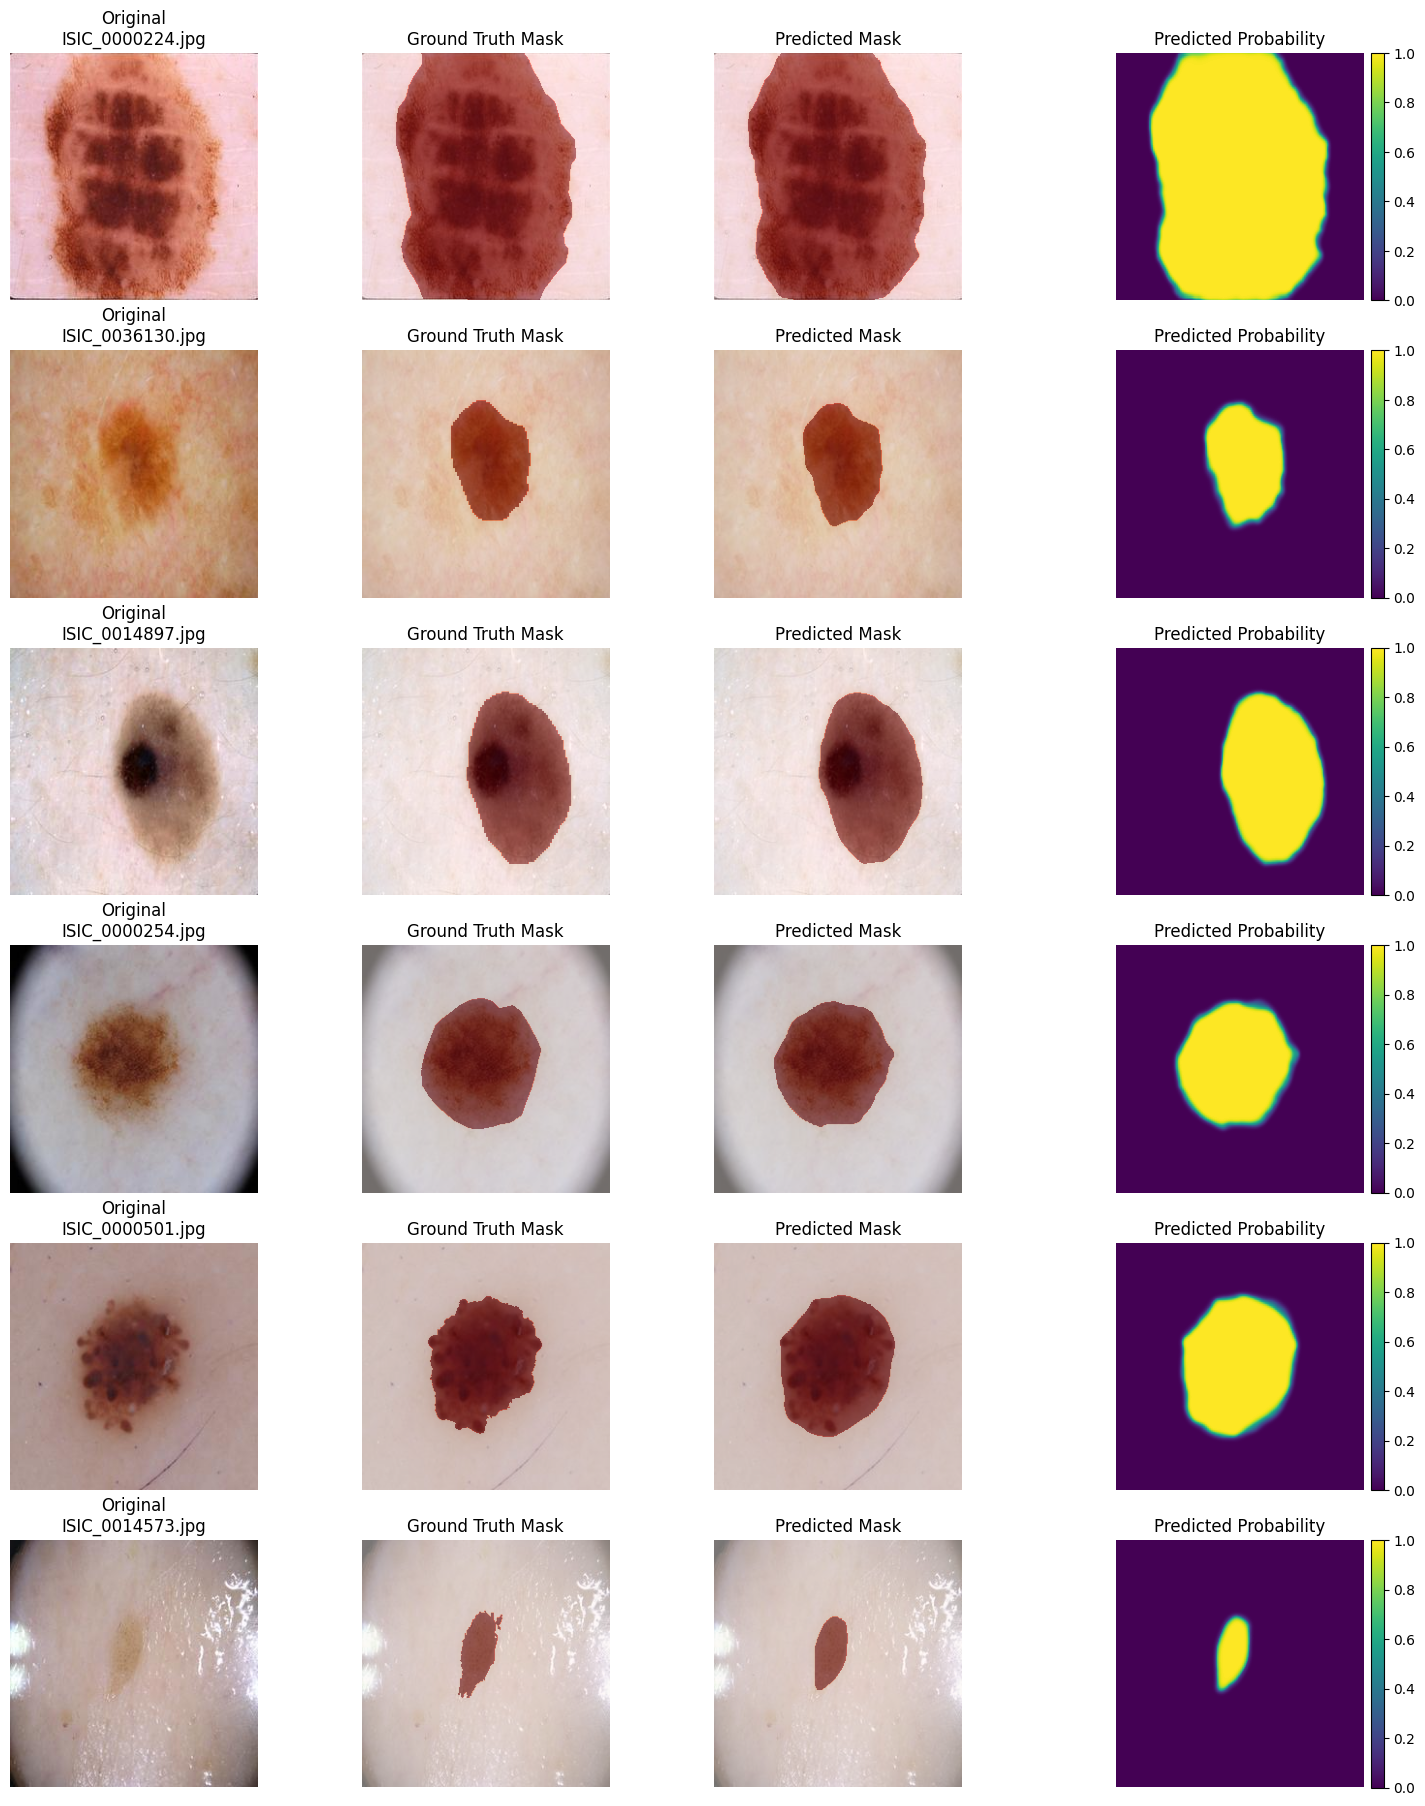

In [53]:
# Visualize predictions on validation images
# Shows original image, ground truth mask, predicted mask, and predicted probability map
show_sample_predictions_overlay(
    seg_model,       # fine-tuned segmentation model
    refiner,         # trained refiner model
    val_imgs,        # list of validation image paths
    val_masks,       # list of corresponding validation mask paths
    n=6,             # number of samples to display
    threshold=0.5,   # threshold for binary prediction
    cmap='Reds',     # colormap for mask overlay
    alpha=0.45,      # transparency of overlay
    figsize=(15,9),  # figure size
    seed=42,         # random seed for reproducibility
    save_path=OUT_PATH  # path to save overlay figure
)

In [54]:
# Glob pattern to load all saved training histories
HISTORY_GLOB = os.path.join(OUTPUT_DIR, "history_*.pkl")

# Window size for smoothing loss/metric curves (>1 applies light smoothing)
SMOOTH_WINDOW = 1  

# Directory to save plots or processed outputs
SAVE_DIR = OUTPUT_DIR
os.makedirs(SAVE_DIR, exist_ok=True)  # create directory if it doesn't exist

In [55]:
def _smooth(x, w=1):
    """
    Smooth a 1D array using a moving average.

    Args:
        x (list or np.ndarray): Input values.
        w (int): Smoothing window size; w <= 1 returns original array.

    Returns:
        np.ndarray: Smoothed array.
    """
    x = np.array(x)
    if w <= 1:  # no smoothing
        return x
    kernel = np.ones(w) / w  # averaging kernel
    return np.convolve(x, kernel, mode='same')  # apply convolution

In [56]:
def load_history_file(path):
    """
    Load a training history pickle file and keep only numeric 1D arrays.

    Args:
        path (str): Path to the .pkl history file.

    Returns:
        dict: Filtered history with numeric 1D arrays and '__name__' key.
    """
    with open(path, 'rb') as f:
        hist = pickle.load(f)

    filtered = {}
    for k, v in hist.items():
        if k == '__name__':  # keep name key
            filtered[k] = v
            continue
        try:
            arr = np.array(v)
            # keep numeric 1D arrays with at least one element
            if arr.size > 0 and arr.ndim == 1 and np.issubdtype(arr.dtype, np.number):
                filtered[k] = arr.astype(float)
        except Exception:
            pass  # ignore incompatible entries

    # ensure '__name__' exists (default: filename without extension)
    base = os.path.splitext(os.path.basename(path))[0]
    filtered['__name__'] = filtered.get('__name__', base)

    return filtered

In [57]:
def find_histories(glob_pattern=HISTORY_GLOB):
    """
    Find all history pickle files matching a glob pattern and load them.

    Args:
        glob_pattern (str): Glob pattern to locate history files.

    Returns:
        list: List of filtered history dictionaries.
    """
    files = sorted(glob.glob(glob_pattern))  # find and sort files
    histories = []

    for p in files:
        try:
            histories.append(load_history_file(p))  # load each history
        except Exception as e:
            print(f"[warn] failed to load history file {p}: {e}")  # skip bad files

    if len(histories) == 0:
        print("[info] no history pickles found at:", glob_pattern)

    return histories


In [58]:
def plot_metrics_flexible(hist, save_dir='plots', smooth_w=1, show_plot=True):
    """
    Plot training/validation metrics from a history dictionary with optional smoothing,
    highlight best epochs, and save plots.

    Args:
        hist (dict): History dictionary containing metrics (e.g., train_loss, val_loss).
        save_dir (str): Directory to save plots.
        smooth_w (int): Window size for smoothing curves.
        show_plot (bool): Whether to display plots interactively.
    """
    name = hist.get('__name__', 'history')  # name for titles and filenames
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)  # create directory if needed

    # Exclude special keys like '__name__'
    keys = [k for k in hist.keys() if k != '__name__']

    # Group metrics by base name (e.g., 'loss', 'accuracy')
    base_metrics = {}
    for k in keys:
        base = k.replace('train_', '').replace('val_', '')
        base_metrics.setdefault(base, []).append(k)

    # Plot each metric group
    for metric, related_keys in base_metrics.items():
        plt.figure(figsize=(10,6))
        epochs = None
        plotted = False

        for k in related_keys:
            vals = hist[k]
            if epochs is None:
                epochs = np.arange(1, len(vals)+1)
            smoothed = _smooth(vals, smooth_w)  # optional smoothing

            # Determine best epoch (min for loss, max otherwise)
            if 'loss' in metric.lower():
                best_idx = np.argmin(vals)
            else:
                best_idx = np.argmax(vals)
            best_val = vals[best_idx]

            # Plot style: dashed for validation, solid for training
            label = k.replace('_', ' ').title()
            linestyle = '--' if 'val' in k else '-'
            color = 'green' if 'val' in k else 'red'

            plt.plot(epochs, smoothed, color=color, linestyle=linestyle, linewidth=2, label=label)
            # Highlight best epoch
            plt.scatter(best_idx + 1, best_val, s=100, c='blue', edgecolors='black',
                        label=f"Best {label} = ep {best_idx + 1}")
            plotted = True

        if not plotted:
            continue

        # Add titles and labels
        plt.title(f'{name} - {metric}', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel(metric, fontsize=12)
        plt.grid(visible=True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=10)
        plt.tight_layout()

        # Save figure
        save_path = os.path.join(save_dir, f'{name}_{metric}_plot.png')
        try:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Saved -> {save_path}")
        except Exception as e:
            print("[warn] could not save plot:", e)

        # Display or close figure
        if show_plot:
            plt.show()
        else:
            plt.close()

In [59]:
def plot_all_histories(histories=None, glob_pattern=HISTORY_GLOB, save_dir=SAVE_DIR, smooth_w=SMOOTH_WINDOW):
    """
    Load all histories (if not provided) and plot metrics for each.
    """
    if histories is None:
        histories = find_histories(glob_pattern)
    if not histories:
        print("[info] no histories to plot")
        return

    for hist in histories:
        plot_metrics_flexible(hist, save_dir=save_dir, smooth_w=smooth_w, show_plot=True)

Saved -> ./lafr_outputs/history_contrastive_loss_plot.png


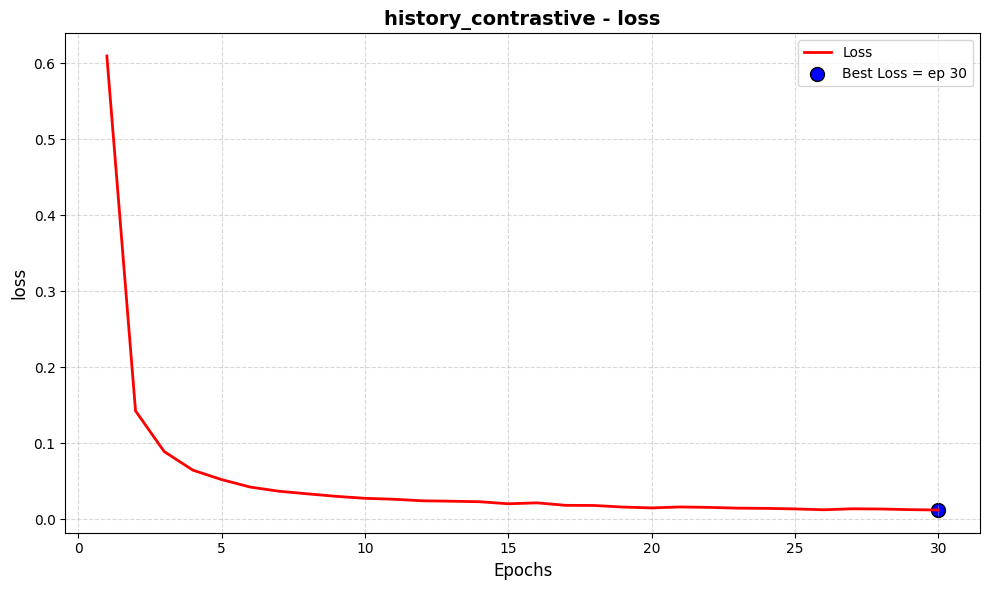

Saved -> ./lafr_outputs/history_finetune_loss_plot.png


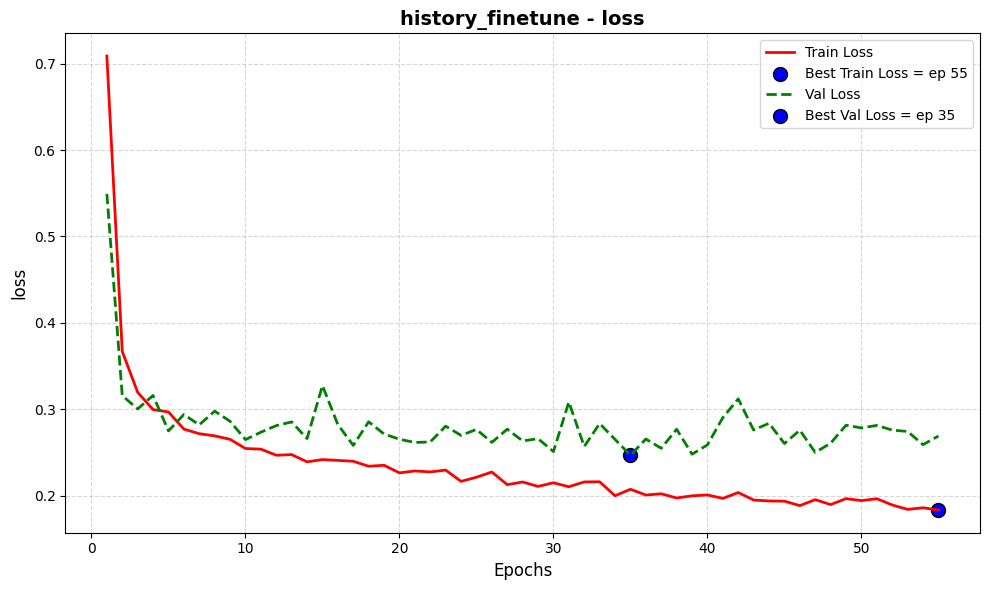

Saved -> ./lafr_outputs/history_finetune_dice_plot.png


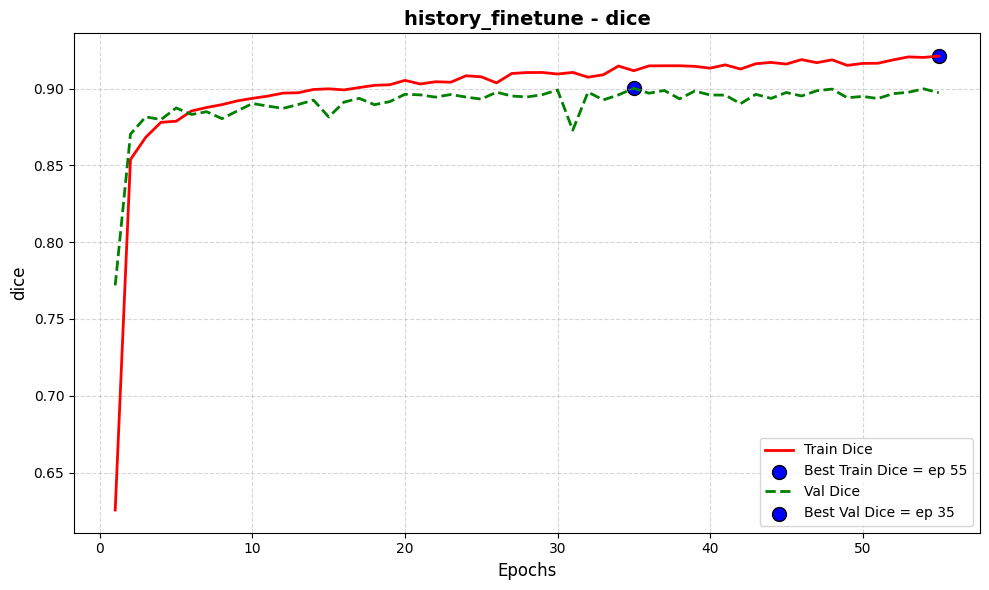

Saved -> ./lafr_outputs/history_finetune_iou_plot.png


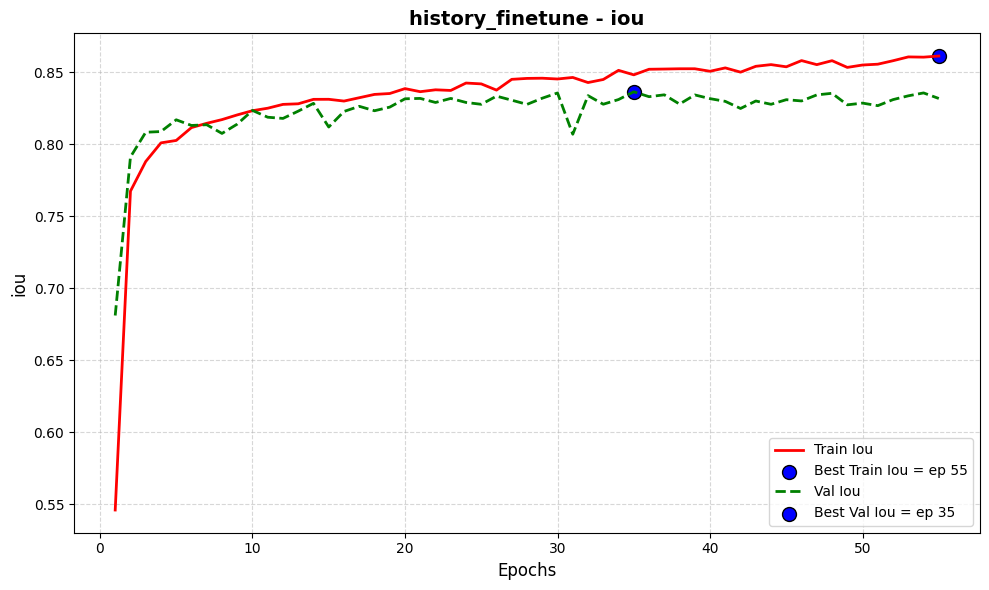

Saved -> ./lafr_outputs/history_finetune_accuracy_plot.png


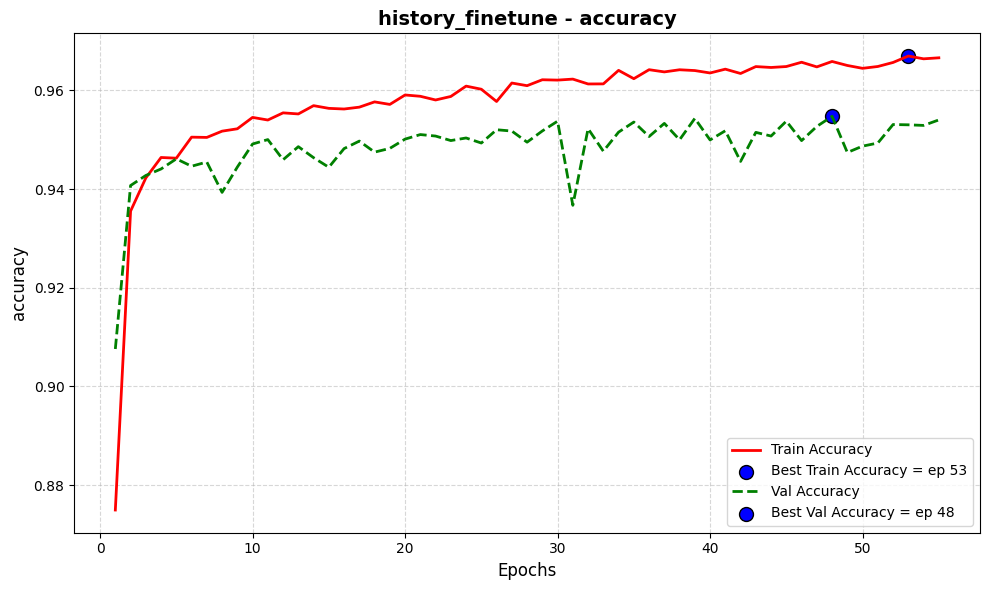

Saved -> ./lafr_outputs/history_finetune_precision_plot.png


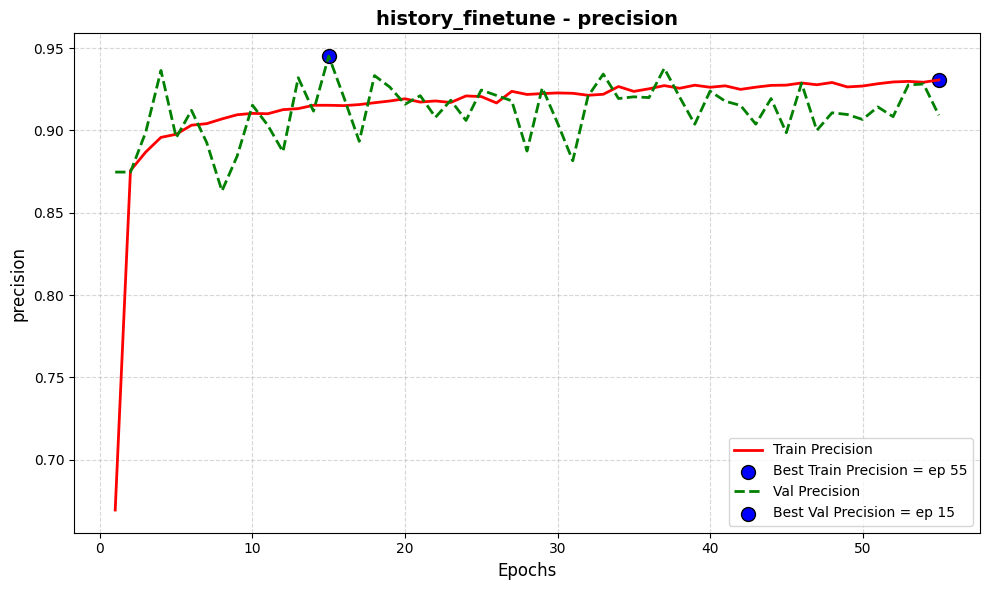

Saved -> ./lafr_outputs/history_finetune_recall_plot.png


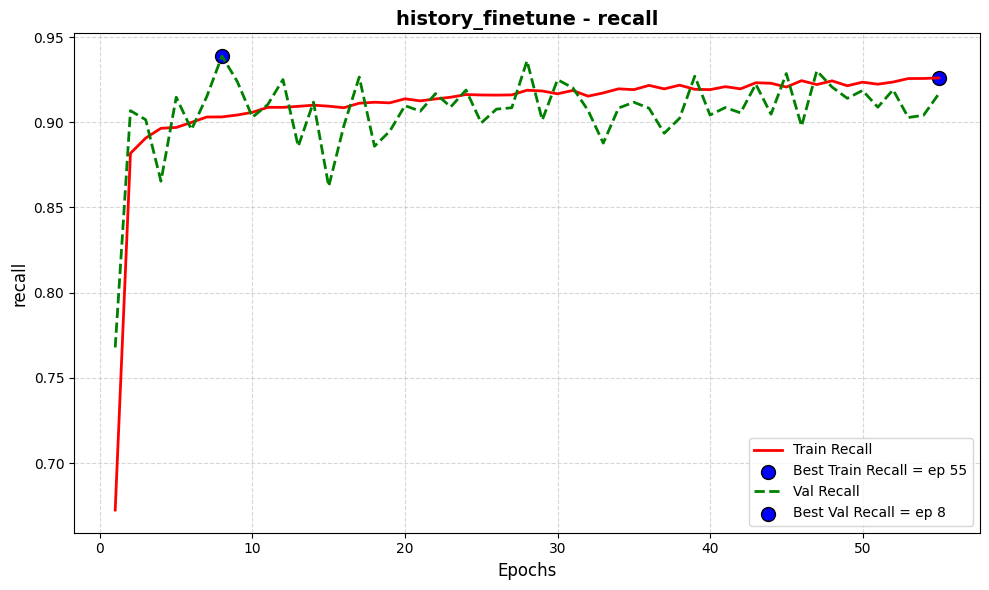

Saved -> ./lafr_outputs/history_refiner_loss_plot.png


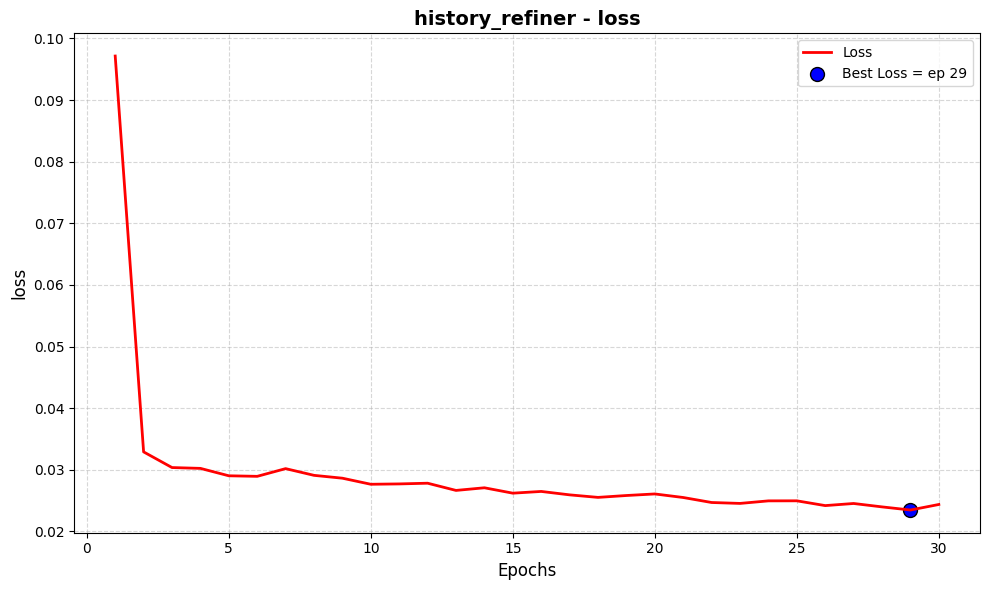

In [60]:
# -----------------------------
# Run everything for plotting
# -----------------------------
plot_all_histories()  # automatically plot all saved histories

In [61]:
# -----------------------
# Parameters for Bootstrap
# -----------------------

MIN_SIZE = 100          # minimum pixel count for valid mask components
N_BOOT = 1000           # number of bootstrap iterations
BOOT_SEED = 42          # random seed for reproducibility
VERBOSE = False         # verbosity flag for logging during bootstrap

TTA_TRANSFORMS = ['none', 'flip_lr', 'flip_ud']  # test-time augmentation transforms
THRESHOLD = 0.5          # probability threshold to binarize masks
VERBOSE = False          # repeated; ensures consistent verbosity setting


In [62]:
# --- Silence TensorFlow and Keras internal logs ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'                 # suppress TF C++ backend messages (0=all, 3=errors only)
tf.get_logger().setLevel('ERROR')                        # show only errors from TF logger
logging.getLogger('tensorflow').setLevel(logging.ERROR)  # suppress verbose TF Python logs

In [63]:
# --- Sanity checks before evaluation or visualization ---
assert 'seg_model' in globals(), "seg_model not found"                   # ensure segmentation model is loaded
assert 'refiner' in globals(), "refiner not found"                       # ensure refiner model is loaded
assert len(val_imgs) == len(val_masks), "val_imgs / val_masks mismatch"  # ensure validation data aligns


In [64]:
def compute_confusion_from_binary(gt_bin, pred_bin):
    """
    Compute confusion matrix components from binary ground truth and prediction.
    Args:
        gt_bin (np.ndarray): Binary ground truth mask (0 or 1).
        pred_bin (np.ndarray): Binary predicted mask (0 or 1).
    Returns:
        tuple: (TP, FP, FN, TN)
    """
    gt = (gt_bin > 0).astype(np.uint8)      # ensure binary format
    pred = (pred_bin > 0).astype(np.uint8)  # ensure binary format

    TP = int(np.sum((pred == 1) & (gt == 1)))  # True Positives
    FP = int(np.sum((pred == 1) & (gt == 0)))  # False Positives
    FN = int(np.sum((pred == 0) & (gt == 1)))  # False Negatives
    TN = int(np.sum((pred == 0) & (gt == 0)))  # True Negatives

    return TP, FP, FN, TN


In [65]:
def metrics_from_confusion(TP, FP, FN, TN):
    """
    Compute common evaluation metrics from confusion matrix components.
    Args:
        TP (int): True Positives
        FP (int): False Positives
        FN (int): False Negatives
        TN (int): True Negatives
    Returns:
        tuple: (dice, iou, accuracy, precision, recall)
    """
    eps = 1e-8  # small constant to avoid division by zero

    dice = (2 * TP) / (2 * TP + FP + FN + eps)         # Dice coefficient
    iou = TP / (TP + FP + FN + eps)                    # Intersection over Union
    total = TP + FP + FN + TN
    acc = (TP + TN) / (total + eps)                    # Overall accuracy
    precision = (TP + eps) / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = (TP + eps) / (TP + FN) if (TP + FN) > 0 else 0.0

    return float(dice), float(iou), float(acc), float(precision), float(recall)


In [66]:
# -----------------------
# Bootstrap helper
# -----------------------
def bootstrap_ci(data, n_boot=N_BOOT, ci=95, seed=BOOT_SEED):
    """
    Compute mean and confidence interval using bootstrap resampling.
    Args:
        data (array-like): Input numeric data.
        n_boot (int): Number of bootstrap samples.
        ci (float): Confidence interval percentage (e.g., 95).
        seed (int): Random seed for reproducibility.
    Returns:
        tuple: (mean, (lower_CI, upper_CI))
    """
    data = np.asarray(data, dtype=float)
    if data.size == 0:
        return float('nan'), (float('nan'), float('nan'))

    rng = np.random.default_rng(seed)
    boot_means = []
    n = data.shape[0]

    for _ in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)  # resample with replacement
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (100 - ci) / 2)          # lower CI bound
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)    # upper CI bound

    return float(np.mean(data)), (float(lower), float(upper))


In [67]:
# -----------------------
# Main evaluation: mean(per-image), global (pixel-wise aggregated), and bootstrap CIs
# -----------------------
def compare_with_without_refiner(seg_model,
                                 refiner,
                                 val_imgs,
                                 val_masks,
                                 threshold=THRESHOLD,
                                 tta_transforms=TTA_TRANSFORMS,
                                 min_size=MIN_SIZE,
                                 n_boot=N_BOOT,
                                 boot_seed=BOOT_SEED,
                                 verbose=VERBOSE):
    """
    Evaluate a segmentation model with and without the refiner, returning:
      - per-image metrics (dice, iou, accuracy, precision, recall + confusion),
      - global (pixel-wise aggregated) metrics computed from summed confusion components,
      - bootstrap 95% confidence intervals for per-image metrics.

    Args:
        seg_model: trained segmentation model (expects single-image input or small TTA stack).
        refiner: trained refiner model (used by predict_with_tta_and_refiner).
        val_imgs (list[str]): list of validation image file paths.
        val_masks (list[str]): list of corresponding validation mask file paths.
        threshold (float): threshold for converting probability maps to binary masks.
        tta_transforms (list): list of TTA names (used by predict_with_tta_and_refiner).
        min_size (int): minimum connected-component size kept in postprocessing.
        n_boot (int): number of bootstrap samples to compute CIs.
        boot_seed (int): seed for bootstrap RNG.
        verbose (bool): verbosity flag for warnings/errors per-image.

    Returns:
        dict: results containing 'per_with', 'per_without', 'mean_per_image',
              'global' and 'bootstrap' entries for downstream analysis.
    """

    # per-image lists: each entry is a dict with metrics + confusion counts for that image
    per_with = []    # dicts with metrics and confusion for seg+refiner
    per_without = [] # dicts with metrics and confusion for seg only

    # aggregated confusion for global (pixel-wise) metrics (sum across all images)
    agg_with_TP = agg_with_FP = agg_with_FN = agg_with_TN = 0
    agg_wo_TP = agg_wo_FP = agg_wo_FN = agg_wo_TN = 0

    skipped = 0
    total = len(val_imgs)

    # Loop over validation images (with progress bar)
    for img_path, mask_path in tqdm(zip(val_imgs, val_masks), total=total, desc="Evaluating", leave=True):
        try:
            # --- Load image and normalize to [0,1] RGB ---
            img_bgr = cv2.imread(img_path)
            if img_bgr is None:
                skipped += 1
                if verbose: print(f"[warn] couldn't read image {img_path}")
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            # --- Load ground truth mask (grayscale) and binarize ---
            gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if gt is None:
                skipped += 1
                if verbose: print(f"[warn] couldn't read mask {mask_path}")
                continue
            gt_bin = (gt > 127).astype(np.uint8)  # binary GT: 0/1

            # ---------- WITH refiner ----------
            # Predict using the segmentation model + refiner with TTA inside helper
            pred_bin_with, _ = predict_with_tta_and_refiner(seg_model, refiner, img_rgb,
                                                            tta_transforms=tta_transforms,
                                                            threshold=threshold)
            # Ensure predicted binary mask matches GT shape; resize if necessary
            if pred_bin_with.shape != gt_bin.shape:
                pred_bin_with = cv2.resize(pred_bin_with.astype(np.uint8),
                                           (gt_bin.shape[1], gt_bin.shape[0]),
                                           interpolation=cv2.INTER_NEAREST)
                pred_bin_with = (pred_bin_with > 0).astype(np.uint8)

            # Compute confusion and derived metrics for the refiner case
            TP_w, FP_w, FN_w, TN_w = compute_confusion_from_binary(gt_bin, pred_bin_with)
            dice_w, iou_w, acc_w, prec_w, rec_w = metrics_from_confusion(TP_w, FP_w, FN_w, TN_w)

            # Store per-image results
            per_with.append({
                'image': os.path.basename(img_path),
                'dice': dice_w, 'iou': iou_w, 'accuracy': acc_w,
                'precision': prec_w, 'recall': rec_w,
                'TP': TP_w, 'FP': FP_w, 'FN': FN_w, 'TN': TN_w
            })

            # Accumulate confusion counts for global (pixel-wise) metrics
            agg_with_TP += TP_w; agg_with_FP += FP_w; agg_with_FN += FN_w; agg_with_TN += TN_w

            # ---------- WITHOUT refiner (TTA average -> postprocess) ----------
            # Build a small TTA stack manually (must match the model's expected preprocessing)
            # Here we use three transforms: original, flip left-right, flip up-down
            tta_stack = np.stack([img_rgb, np.fliplr(img_rgb), np.flipud(img_rgb)])  # (3,H,W,C)

            # Run the segmentation model on the TTA stack; returns per-tta masks
            preds = seg_model.predict(tta_stack, verbose=0)  # (3,H,W,1) or (3,H,W)

            # Average TTA predictions to produce a single soft (probability) mask
            avg_mask = np.mean(preds, axis=0)
            if avg_mask.ndim == 3 and avg_mask.shape[-1] == 1:
                avg_mask = np.squeeze(avg_mask, axis=-1)

            # Resize avg_mask to GT shape if needed (interpolate probabilities)
            if avg_mask.shape[:2] != gt_bin.shape[:2]:
                avg_mask = cv2.resize(avg_mask, (gt_bin.shape[1], gt_bin.shape[0]), interpolation=cv2.INTER_LINEAR)

            # Postprocess the averaged soft mask (threshold + keep largest component, min_size)
            pred_bin_without = postprocess_mask(avg_mask, threshold=threshold, min_size=min_size).astype(np.uint8)

            # Compute confusion and metrics for the segmentation-only case
            TP_wo, FP_wo, FN_wo, TN_wo = compute_confusion_from_binary(gt_bin, pred_bin_without)
            dice_wo, iou_wo, acc_wo, prec_wo, rec_wo = metrics_from_confusion(TP_wo, FP_wo, FN_wo, TN_wo)

            # Store per-image results (without refiner)
            per_without.append({
                'image': os.path.basename(img_path),
                'dice': dice_wo, 'iou': iou_wo, 'accuracy': acc_wo,
                'precision': prec_wo, 'recall': rec_wo,
                'TP': TP_wo, 'FP': FP_wo, 'FN': FN_wo, 'TN': TN_wo
            })

            # Accumulate confusion counts for segmentation-only global metrics
            agg_wo_TP += TP_wo; agg_wo_FP += FP_wo; agg_wo_FN += FN_wo; agg_wo_TN += TN_wo

        except Exception as e:
            # If an error occurs for one image, skip it but keep going (robust evaluation)
            skipped += 1
            if verbose:
                print(f"[error] processing {img_path}: {e}")
            continue

    # -----------------------
    # Post-loop: convert collected per-image dicts into numeric arrays
    # -----------------------
    def to_arr(list_of_dicts, key):
        # Helper: extract a numeric column from list-of-dicts; return empty array if none
        return np.array([d[key] for d in list_of_dicts], dtype=np.float64) if list_of_dicts else np.array([])

    # Per-image metric arrays for both scenarios
    dice_with = to_arr(per_with, 'dice')
    iou_with  = to_arr(per_with, 'iou')
    acc_with  = to_arr(per_with, 'accuracy')
    prec_with = to_arr(per_with, 'precision')
    rec_with  = to_arr(per_with, 'recall')

    dice_without = to_arr(per_without, 'dice')
    iou_without  = to_arr(per_without, 'iou')
    acc_without  = to_arr(per_without, 'accuracy')
    prec_without = to_arr(per_without, 'precision')
    rec_without  = to_arr(per_without, 'recall')

    # Safe mean helper (returns NaN if array empty)
    def mean_safe(arr): return float(np.mean(arr)) if arr.size > 0 else float('nan')

    # -----------------------
    # Mean (per-image) summaries
    # -----------------------
    mean_with = {
        'dice': mean_safe(dice_with), 'iou': mean_safe(iou_with), 'acc': mean_safe(acc_with),
        'prec': mean_safe(prec_with), 'rec': mean_safe(rec_with)
    }
    mean_without = {
        'dice': mean_safe(dice_without), 'iou': mean_safe(iou_without), 'acc': mean_safe(acc_without),
        'prec': mean_safe(prec_without), 'rec': mean_safe(rec_without)
    }

    # -----------------------
    # Global (pixel-wise aggregated) metrics computed from summed confusion
    # -----------------------
    # metrics_from_confusion returns (dice,iou,acc,precision,recall)
    global_with = metrics_from_confusion(agg_with_TP, agg_with_FP, agg_with_FN, agg_with_TN)
    global_without = metrics_from_confusion(agg_wo_TP, agg_wo_FP, agg_wo_FN, agg_wo_TN)

    # -----------------------
    # Bootstrap confidence intervals for per-image metrics
    # -----------------------
    # Use bootstrap_ci to compute mean and (lower,upper) CI for each metric array
    dice_with_mean, dice_with_ci = bootstrap_ci(dice_with, n_boot=n_boot, ci=95, seed=boot_seed)
    iou_with_mean,  iou_with_ci  = bootstrap_ci(iou_with,  n_boot=n_boot, ci=95, seed=boot_seed)
    acc_with_mean,  acc_with_ci  = bootstrap_ci(acc_with,  n_boot=n_boot, ci=95, seed=boot_seed)
    prec_with_mean, prec_with_ci = bootstrap_ci(prec_with, n_boot=n_boot, ci=95, seed=boot_seed)
    rec_with_mean,  rec_with_ci  = bootstrap_ci(rec_with,  n_boot=n_boot, ci=95, seed=boot_seed)

    dice_wo_mean, dice_wo_ci = bootstrap_ci(dice_without, n_boot=n_boot, ci=95, seed=boot_seed)
    iou_wo_mean,  iou_wo_ci  = bootstrap_ci(iou_without,  n_boot=n_boot, ci=95, seed=boot_seed)
    acc_wo_mean,  acc_wo_ci  = bootstrap_ci(acc_without,  n_boot=n_boot, ci=95, seed=boot_seed)
    prec_wo_mean, prec_wo_ci = bootstrap_ci(prec_without, n_boot=n_boot, ci=95, seed=boot_seed)
    rec_wo_mean,  rec_wo_ci  = bootstrap_ci(rec_without,  n_boot=n_boot, ci=95, seed=boot_seed)

    # -----------------------
    # Print summary to console (human-readable)
    # -----------------------
    print("\n===== Evaluation summary =====")
    print(f"Images evaluated: {len(per_with)} (with refiner) / {len(per_without)} (without refiner)  skipped: {skipped}\n")

    print("---- Mean (per-image) metrics ----")
    print(f"WITH refiner    -> Dice: {mean_with['dice']:.4f}, IoU: {mean_with['iou']:.4f}, Acc: {mean_with['acc']:.4f}, Prec: {mean_with['prec']:.4f}, Rec: {mean_with['rec']:.4f}")
    print(f"WITHOUT refiner -> Dice: {mean_without['dice']:.4f}, IoU: {mean_without['iou']:.4f}, Acc: {mean_without['acc']:.4f}, Prec: {mean_without['prec']:.4f}, Rec: {mean_without['rec']:.4f}\n")

    print("---- Global (pixel-wise aggregated) metrics ----")
    print(f"WITH refiner    -> Dice: {global_with[0]:.4f}, IoU: {global_with[1]:.4f}, Acc: {global_with[2]:.4f}, Prec: {global_with[3]:.4f}, Rec: {global_with[4]:.4f}")
    print(f"WITHOUT refiner -> Dice: {global_without[0]:.4f}, IoU: {global_without[1]:.4f}, Acc: {global_without[2]:.4f}, Prec: {global_without[3]:.4f}, Rec: {global_without[4]:.4f}\n")

    print("---- Bootstrap 95% CI (per-image) ----")
    def fmt(mean, ci): return f"{mean:.4f} (95% CI: {ci[0]:.4f}–{ci[1]:.4f})"
    print(f"WITH refiner    -> Dice: {fmt(dice_with_mean, dice_with_ci)}")
    print(f"                -> IoU:  {fmt(iou_with_mean, iou_with_ci)}")
    print(f"                -> Acc:  {fmt(acc_with_mean, acc_with_ci)}")
    print(f"                -> Prec: {fmt(prec_with_mean, prec_with_ci)}")
    print(f"                -> Rec:  {fmt(rec_with_mean, rec_with_ci)}\n")

    print(f"WITHOUT refiner -> Dice: {fmt(dice_wo_mean, dice_wo_ci)}")
    print(f"                -> IoU:  {fmt(iou_wo_mean, iou_wo_ci)}")
    print(f"                -> Acc:  {fmt(acc_wo_mean, acc_wo_ci)}")
    print(f"                -> Prec: {fmt(prec_wo_mean, prec_wo_ci)}")
    print(f"                -> Rec:  {fmt(rec_wo_mean, rec_wo_ci)}")
    print("========================================\n")

    # -----------------------
    # Return a structured results dict for programmatic use
    # -----------------------
    results = {
        'per_with': per_with,
        'per_without': per_without,
        'mean_per_image': {'with': mean_with, 'without': mean_without},
        'global': {'with': global_with, 'without': global_without},
        'bootstrap': {
            'with': {
                'dice': (dice_with_mean, dice_with_ci), 'iou': (iou_with_mean, iou_with_ci),
                'acc': (acc_with_mean, acc_with_ci), 'prec': (prec_with_mean, prec_with_ci),
                'rec': (rec_with_mean, rec_with_ci)
            },
            'without': {
                'dice': (dice_wo_mean, dice_wo_ci), 'iou': (iou_wo_mean, iou_wo_ci),
                'acc': (acc_wo_mean, acc_wo_ci), 'prec': (prec_wo_mean, prec_wo_ci),
                'rec': (rec_wo_mean, rec_wo_ci)
            }
        }
    }
    return results

In [68]:
# -----------------------
# Call the main evaluation function
# -----------------------
# This will evaluate the segmentation model with and without the refiner on the validation set,
# computing per-image metrics, global pixel-wise metrics, and bootstrap confidence intervals.
results = compare_with_without_refiner(
    seg_model,         # trained segmentation model
    refiner,           # trained refiner model
    val_imgs,          # list of validation image file paths
    val_masks,         # list of corresponding validation mask paths
    threshold=THRESHOLD,        # probability threshold for binary masks
    tta_transforms=TTA_TRANSFORMS,  # list of TTA transformations to use
    min_size=MIN_SIZE,           # minimum connected component size for postprocessing
    n_boot=N_BOOT,               # number of bootstrap samples for confidence intervals
    boot_seed=BOOT_SEED,         # random seed for bootstrap sampling
    verbose=False                # disable per-image warnings for clean output
)


Evaluating: 100%|██████████| 370/370 [01:43<00:00,  3.59it/s]



===== Evaluation summary =====
Images evaluated: 370 (with refiner) / 370 (without refiner)  skipped: 0

---- Mean (per-image) metrics ----
WITH refiner    -> Dice: 0.9028, IoU: 0.8418, Acc: 0.9560, Prec: 0.9342, Rec: 0.9051
WITHOUT refiner -> Dice: 0.8238, IoU: 0.7265, Acc: 0.9351, Prec: 0.8839, Rec: 0.8129

---- Global (pixel-wise aggregated) metrics ----
WITH refiner    -> Dice: 0.9059, IoU: 0.8280, Acc: 0.9560, Prec: 0.9179, Rec: 0.8942
WITHOUT refiner -> Dice: 0.8601, IoU: 0.7545, Acc: 0.9351, Prec: 0.8776, Rec: 0.8433

---- Bootstrap 95% CI (per-image) ----
WITH refiner    -> Dice: 0.9028 (95% CI: 0.8887–0.9152)
                -> IoU:  0.8418 (95% CI: 0.8253–0.8572)
                -> Acc:  0.9560 (95% CI: 0.9469–0.9634)
                -> Prec: 0.9342 (95% CI: 0.9206–0.9460)
                -> Rec:  0.9051 (95% CI: 0.8900–0.9187)

WITHOUT refiner -> Dice: 0.8238 (95% CI: 0.8058–0.8403)
                -> IoU:  0.7265 (95% CI: 0.7065–0.7452)
                -> Acc:  0.9351 (95%

In [69]:
# For the constrative model 
contrastive_model.summary()

Model: "xception_encoder_proj"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_base (Functional)      │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,976,232 (83.83 MB)

 Trainable params: 21,832,520 (83.28 MB)

 Non-trainable params: 143,712 (561.38 KB)

In [70]:
# For the main segmentation model
seg_model.summary()

Model: "XceptionUNet_TF_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 127, 127,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 127, 127,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 127, 127,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 125, 125,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 125, 125,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 125, 125,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 125, 125,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 125, 125,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 125, 125,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 125, 125,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 125, 125,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 63, 63,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 63, 63,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 63, 63,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 63, 63,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 63, 63,    │          0 │ add[0][0]       

 Total params: 22,391,451 (85.42 MB)

 Trainable params: 22,348,187 (85.25 MB)

 Non-trainable params: 43,264 (169.00 KB)

In [71]:
# For the refiner model
refiner.summary()

Model: "refiner_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │      1,184 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │     36,928 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    147,584 │ dropout_2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_25[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │    590,080 │ dropout_3[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_26[0][0] 

 Total params: 7,846,945 (29.93 MB)

 Trainable params: 7,846,945 (29.93 MB)

 Non-trainable params: 0 (0.00 B)